
# 🏁 iRacing Telemetry → Coaching Pipeline (End-to-End)

This notebook builds a **complete, reproducible pipeline** to turn iRacing telemetry into **sector-level coaching**.

You will:
1. **Load** raw telemetry (from `.ibt` via `irsdk` or from a pre-saved CSV).
2. **Clean & normalize** the signals; convert units.
3. **Align laps** by distance percentage and visualize **time loss vs reference**.
4. **Split the lap into sectors**, compute sector statistics and deltas.
5. Build a **robust sector reference** (median of the top K% fastest laps).
6. Engineer features, **train a regressor** (LightGBM fallback to GradientBoosting), and report cross-validated metrics.
7. Apply a **per-sector residual bias correction** and re-evaluate metrics.
8. Generate **rule-based coaching** in milliseconds (ms).
9. (Optional) Call a **local LLM via Ollama** to produce **professional English coaching** using a structured JSON context.

> **Note:** All visuals use Matplotlib. No external internet is required. If `irsdk` is unavailable, you can work from CSV.



## 1. Environment checks & configuration

Fill the paths and flags below. If you don't have `.ibt` or `irsdk`, set `USE_IBT=False` and point to a CSV created earlier.


In [37]:

# --- Imports
import os, folium
from pathlib import Path
from typing import Dict, List, Tuple, Any, Optional
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ML / Explainability (LightGBM optional)
try:
    import lightgbm as lgb
    LGB_AVAILABLE = True
except Exception:
    LGB_AVAILABLE = False

from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.model_selection import GroupKFold, train_test_split
from sklearn.metrics import mean_absolute_error
from sklearn.inspection import permutation_importance

# Optional irsdk (for .ibt)
try:
    import irsdk
    IRSDK_AVAILABLE = True
except Exception:
    IRSDK_AVAILABLE = False


# --- Paths & Parameters
USE_IBT = True  # set True to read a .ibt with irsdk if available




# --- 1. EXTRAÇÃO DOS DADOS DO ARQUIVO .IBT ---
root_path = "/Users/morsinaldo/Developer/Racing4all/Iracing/data/"
google_drive_path = "G:/Meu Drive/Estudos/Datasets - Simracing/Mazda - Charlotte"

#ibt_file = google_drive_path + "/mx5 mx52016_charlotte 2025 roval2025 2026-01-22 14-13-43(Morsinaldo).ibt"
#ibt_file = google_drive_path + "/mx5 mx52016_charlotte 2025 roval2025 2025-11-26 13-56-41.ibt" #Tomaz


# Core pipeline settings
N_SECTORS = 4               # number of sectors to split the track
BASE_GRID_LEN = 1000
TOPK_PERCENT = 0.30          # robust sector reference: median of fastest top K%
PACE_THRESHOLD_MS = 3000.0   # drop laps whose sum of positive sector losses > 2s
CLIP_MS = 1500.0             # clip training target (ms)
SEQ_LEN = 128                # per-sector resampling for stability
SEED = 42




## 2. Data loading

Two options:

- **From `.ibt` via `irsdk`** (preferred for raw sessions).
- **From CSV** (if you already exported or `irsdk` is not available).

The notebook will try what you configured above.


In [38]:
USE_IBT = True
IRSDK_AVAILABLE = True 

def load_from_ibt(ibt_path: Path) -> pd.DataFrame:
    """
    Loads binary IBT file using irsdk.
    """
    if not IRSDK_AVAILABLE:
        raise RuntimeError("irsdk is not available in this environment.")
    if not ibt_path.exists():
        raise FileNotFoundError(f".ibt file not found: {ibt_path}")
    
    ibt = irsdk.IBT()
    try:
        ibt.open(str(ibt_path))
        channels = [
        'Lat',
        'Lon',
        # Tempo / lap
        'SessionTime',
        'Lap',
        'LapDistPct',

        # Inputs
        'Throttle',
        'ThrottleRaw',
        'Brake',
        'BrakeRaw',
        'SteeringWheelAngle',

        # Dinâmica
        'Speed',
        'LatAccel',
        'LongAccel',
        'YawRate',

        # Contexto
        'RPM',
        'Gear',
        'BrakeABSactive',
    ]
        data = {ch: ibt.get_all(ch) for ch in channels}
    except Exception as e:
        print(f"[ERROR] Failed to open {ibt_path}: {e}")
        return pd.DataFrame() 
    finally:
        ibt.close()
    return pd.DataFrame(data)


ibt_file = google_drive_path + "/mx5 mx52016_charlotte 2025 roval2025 2025-11-26 13-56-41.ibt" #Tomaz
raw_df = load_from_ibt(Path(ibt_file))
raw_df.head()

,Lat,Lon,SessionTime,Lap,LapDistPct,Throttle,ThrottleRaw,Brake,BrakeRaw,SteeringWheelAngle,Speed,LatAccel,LongAccel,YawRate,RPM,Gear,BrakeABSactive
0,0.000000,0.000000,59.700001,0,0.000000,0.0,0.0,1.0,0.0,-0.096121,0.000000,-0.007257,-0.064572,-0.000629,300.0,0,False
1,35.350725,-80.685287,59.716668,0,0.065121,0.0,0.0,1.0,0.0,-0.096121,0.004355,0.129972,0.280290,-0.002115,300.0,0,False
2,35.350725,-80.685287,59.733334,0,0.065122,0.0,0.0,1.0,0.0,-0.096121,0.005736,-0.681544,0.591270,-0.002677,300.0,0,False
3,35.350725,-80.685287,59.750001,0,0.065121,0.0,0.0,1.0,0.0,-0.096121,0.023581,-0.532607,0.959497,-0.000691,300.0,0,False
4,35.350725,-80.685287,59.766668,0,0.065121,0.0,0.0,1.0,0.0,-0.096121,0.039354,-0.451288,0.910195,0.003051,300.0,0,False


# 3) Data Cleaning



In [39]:

def lap_time_seconds(g: pd.DataFrame) -> float:
    gs = g.sort_values("SessionTime")
    return float(gs["SessionTime"].iloc[-1] - gs["SessionTime"].iloc[0])

def build_lap_validity_table(
    df: pd.DataFrame,
    manual_invalid: Optional[set] = None,
    low_speed_kph: float = 10.0,
    min_max_speed_kph: float = 60.0,
    min_completed_pct: float = 0.98,
    max_lap_time_s: float = 120.0,
) -> pd.DataFrame:

    manual_invalid = manual_invalid or set()
    rows = []

    for lap, g in df.groupby("Lap", sort=True):
        gs = g.sort_values("SessionTime").copy()
        lap_time = lap_time_seconds(gs)

        rows.append({
            "Lap": int(lap),
            "LapTime_s": float(lap_time),
            "CompletedPct": float(gs["LapDistPct"].max()),
            "FracLowSpeed": float((gs["Speed_KPH"] < low_speed_kph).mean()),
            "MaxSpeed_kph": float(gs["Speed_KPH"].max()),
        })

    lap_df = pd.DataFrame(rows).sort_values("Lap").reset_index(drop=True)

    valid = (
        (lap_df["CompletedPct"] >= min_completed_pct) &
        (~lap_df["Lap"].isin(manual_invalid)) &
        (lap_df["FracLowSpeed"] <= 0.25) &
        (lap_df["MaxSpeed_kph"] >= min_max_speed_kph) &
        (lap_df["LapTime_s"] <= max_lap_time_s)
    )
    lap_df["Valid"] = valid

    if lap_df["Valid"].sum() >= 5:
        q1, q3 = lap_df.loc[lap_df["Valid"], "LapTime_s"].quantile([0.25, 0.75])
        iqr = float(q3 - q1)
        hi = float(q3 + 1.5 * iqr)
        lo = max(0.0, float(q1 - 1.5 * iqr))
        lap_df.loc[:, "Valid"] &= lap_df["LapTime_s"].between(lo, hi)

    return lap_df

def align_lap_by_dist(g: pd.DataFrame, grid: np.ndarray) -> Dict[str, np.ndarray]:
    g = g.sort_values("LapDistPct").drop_duplicates(subset=["LapDistPct"], keep="first")
    if g.empty:
        return {}

    t_rel = g["SessionTime"] - g["SessionTime"].iloc[0]
    x = g["LapDistPct"].to_numpy()

    if len(x) < 2 or np.allclose(x.max() - x.min(), 0):
        return {}

    def interp(y: np.ndarray) -> np.ndarray:
        return np.interp(grid, x, y)

    out = {
        "LapDistPct": grid,
        
        "t_rel": interp(t_rel.to_numpy()),

        # Cinemática
        "speed": interp(g["Speed_KPH"].to_numpy()),

        # Inputs
        "throttle": interp(g["Throttle_Pct"].to_numpy()),
        "brake": interp(g["Brake_Pct"].to_numpy()),

        # Direção
        "SteeringWheelAngle": interp(g["SteeringWheelAngle"].to_numpy()),
    }

    # Dinâmica lateral / longitudinal
    if "LatAccel" in g.columns:
        out["LatAccel"] = interp(g["LatAccel"].to_numpy())
    if "LongAccel" in g.columns:
        out["LongAccel"] = interp(g["LongAccel"].to_numpy())
    if "YawRate" in g.columns:
        out["YawRate"] = interp(g["YawRate"].to_numpy())

    # Contexto (opcional)
    if "RPM" in g.columns:
        out["RPM"] = interp(g["RPM"].to_numpy())
    if "Gear" in g.columns:
        out["Gear"] = interp(g["Gear"].to_numpy())

    return out


def format_laptime(seconds: float) -> str:
    """Converte um tempo em segundos para o formato de string MM:SS.ms."""
    if pd.isna(seconds):
        return "N/A"
    # Calcula os minutos
    minutes = int(seconds // 60)
    # Calcula os segundos restantes com milissegundos
    remaining_seconds = seconds % 60
    # Retorna a string formatada, garantindo dois dígitos para os minutos
    # e preenchimento com zero para os segundos (ex: 01:05.123)
    return f"{minutes:02d}:{remaining_seconds:06.3f}"

def normalize_lapdistpct(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    if "LapDistPct" not in df.columns:
        return df

    mx = df["LapDistPct"].max()
    # Heurística simples: se parece 0-100, normaliza
    if pd.notna(mx) and mx > 1.5:
        df["LapDistPct"] = df["LapDistPct"] / 100.0

    return df

def basic_clean_and_units(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df.replace([np.inf, -np.inf], np.nan, inplace=True)

    # Unidades (antes de dropna)
    if "Speed_KPH" not in df.columns and "Speed" in df.columns:
        df["Speed_KPH"] = df["Speed"] * 3.6
    if "Throttle_Pct" not in df.columns and "Throttle" in df.columns:
        df["Throttle_Pct"] = df["Throttle"] * 100.0
    if "Brake_Pct" not in df.columns and "Brake" in df.columns:
        df["Brake_Pct"] = df["Brake"] * 100.0

    # Normaliza LapDistPct
    df = normalize_lapdistpct(df)

    required = ["Lap", "SessionTime", "LapDistPct", "Speed_KPH", "Throttle_Pct", "Brake_Pct"]
    required = [c for c in required if c in df.columns]
    df = df.dropna(subset=required)

    return df

In [40]:
tomaz_df = basic_clean_and_units(raw_df)
tomaz_df.head()

,Lat,Lon,SessionTime,Lap,LapDistPct,Throttle,ThrottleRaw,Brake,BrakeRaw,SteeringWheelAngle,Speed,LatAccel,LongAccel,YawRate,RPM,Gear,BrakeABSactive,Speed_KPH,Throttle_Pct,Brake_Pct
0,0.000000,0.000000,59.700001,0,0.000000,0.0,0.0,1.0,0.0,-0.096121,0.000000,-0.007257,-0.064572,-0.000629,300.0,0,False,0.000000,0.0,100.0
1,35.350725,-80.685287,59.716668,0,0.065121,0.0,0.0,1.0,0.0,-0.096121,0.004355,0.129972,0.280290,-0.002115,300.0,0,False,0.015679,0.0,100.0
2,35.350725,-80.685287,59.733334,0,0.065122,0.0,0.0,1.0,0.0,-0.096121,0.005736,-0.681544,0.591270,-0.002677,300.0,0,False,0.020651,0.0,100.0
3,35.350725,-80.685287,59.750001,0,0.065121,0.0,0.0,1.0,0.0,-0.096121,0.023581,-0.532607,0.959497,-0.000691,300.0,0,False,0.084890,0.0,100.0
4,35.350725,-80.685287,59.766668,0,0.065121,0.0,0.0,1.0,0.0,-0.096121,0.039354,-0.451288,0.910195,0.003051,300.0,0,False,0.141674,0.0,100.0



## 4. Lap validity & reference selection

We mark laps as valid and pick a **reference lap** (fastest among valid). We'll also pick a **target lap** to compare.


In [41]:
INVALID_LAPS = set()
TARGET_LAP_TO_ANALYZE = 4

lap_df = build_lap_validity_table(tomaz_df, manual_invalid=INVALID_LAPS)

lap_df["LapTime_Formatted"] = lap_df["LapTime_s"].apply(format_laptime)

display(lap_df[["Lap", "Valid", "LapTime_s", "LapTime_Formatted"]])

valid_laps = lap_df[lap_df["Valid"]]["Lap"].tolist()

if not valid_laps:
    raise RuntimeError("Nenhuma volta válida encontrada.")

# --- Referência: volta mais rápida válida ---
ref_row = lap_df[lap_df["Valid"]].sort_values("LapTime_s").iloc[0]
ref_lap = int(ref_row["Lap"])

# --- Target: tentativa manual com fallback ---
target_lap = TARGET_LAP_TO_ANALYZE

if target_lap not in valid_laps:
    print(
        f"⚠️ Volta alvo {target_lap} não existe ou é inválida.\n"
        f"Usando a volta válida mais lenta como fallback."
    )
    target_lap = max(valid_laps)

target_row = lap_df.loc[lap_df["Lap"] == target_lap].iloc[0]

print(f"Reference lap: {ref_lap}  ({format_laptime(ref_row['LapTime_s'])})")
print(f"Target lap   : {target_lap}  ({format_laptime(target_row['LapTime_s'])})")


,Lap,Valid,LapTime_s,LapTime_Formatted
0,0,False,2917.466667,48:37.467
1,1,True,98.266667,01:38.267
2,2,True,99.416667,01:39.417
3,3,True,98.083333,01:38.083
4,4,True,97.283333,01:37.283
5,5,False,100.250000,01:40.250
6,6,True,97.933333,01:37.933
7,7,True,97.283333,01:37.283
8,8,True,99.066667,01:39.067
9,9,True,98.400000,01:38.400


Reference lap: 19  (01:36.733)
Target lap   : 4  (01:37.283)


# Import other driver telemetry

In [42]:
# --- 1. EXTRAÇÃO DOS DADOS DO ARQUIVO .IBT ---
root_path = "/Users/morsinaldo/Developer/Racing4all/Iracing/data/"
google_drive_path = "G:/Meu Drive/Estudos/Datasets - Simracing/Mazda - Charlotte"

ibt_file = google_drive_path + "/mx5 mx52016_charlotte 2025 roval2025 2026-01-27 12-19-00.ibt"

raw_morsinaldo_df = load_from_ibt(Path(ibt_file))
#Data Cleaning
morsinaldo_df = basic_clean_and_units(raw_morsinaldo_df)
morsinaldo_df.head()

,Lat,Lon,SessionTime,Lap,LapDistPct,Throttle,ThrottleRaw,Brake,BrakeRaw,SteeringWheelAngle,Speed,LatAccel,LongAccel,YawRate,RPM,Gear,BrakeABSactive,Speed_KPH,Throttle_Pct,Brake_Pct
0,0.000000,0.000000,91.716666,0,0.000000,0.0,0.0,1.0,0.0,-0.001389,0.000000,0.026483,-0.071254,-0.001445,300.0,0,False,0.000000,0.0,100.0
1,35.350725,-80.685287,91.733333,0,0.065121,0.0,0.0,1.0,0.0,-0.001389,0.005291,0.166895,0.270440,-0.001393,300.0,0,False,0.019048,0.0,100.0
2,35.350725,-80.685287,91.749999,0,0.065122,0.0,0.0,1.0,0.0,-0.001389,0.004464,-0.674376,0.588471,-0.001606,300.0,0,False,0.016072,0.0,100.0
3,35.350725,-80.685287,91.766666,0,0.065122,0.0,0.0,1.0,0.0,-0.001389,0.022396,-0.553882,0.963151,0.000505,300.0,0,False,0.080624,0.0,100.0
4,35.350725,-80.685287,91.783333,0,0.065121,0.0,0.0,1.0,0.0,-0.001389,0.038459,-0.472476,0.931120,0.004036,300.0,0,False,0.138453,0.0,100.0


In [43]:
#Cleaning lap time
INVALID_LAPS = set()  # add warm-up, pit-in/out laps if needed
target_lap = 10 # Tentativa de usar a volta desejada


#retorna um DataFrame com a coluna 'LapTime_s'
lap_df = build_lap_validity_table(morsinaldo_df, manual_invalid=INVALID_LAPS)

# 1. Adicionamos uma nova coluna ao DataFrame com o tempo formatado
lap_df['LapTime_Formatted'] = lap_df['LapTime_s'].apply(format_laptime)

valid_laps = lap_df[lap_df["Valid"]]["Lap"].tolist()

# Exibimos o DataFrame com a nova coluna para melhor visualização
display(lap_df[['Lap', 'Valid', 'LapTime_s', 'LapTime_Formatted']])

if not valid_laps:
    raise RuntimeError("Nenhuma volta válida encontrada para este piloto.")

# Volta de referência (mais rápida válida)
ref_row_morsinaldo = lap_df[lap_df["Valid"]].sort_values("LapTime_s").iloc[0]
ref_lap = int(ref_row_morsinaldo["Lap"])


if target_lap not in valid_laps:
    print(
        f"⚠️ Volta alvo {target_lap} não disponível para este piloto.\n"
        f"Usando a volta válida mais lenta como fallback."
    )
    target_lap = max(valid_laps)
    
target_row = lap_df[lap_df["Lap"] == target_lap].iloc[0]

print(f"Reference lap: {ref_lap}  ({format_laptime(ref_row['LapTime_s'])})")
print(f"Target lap   : {target_lap}  ({format_laptime(target_row['LapTime_s'])})")


,Lap,Valid,LapTime_s,LapTime_Formatted
0,0,False,1016.950000,16:56.950
1,1,True,101.933333,01:41.933
2,2,True,98.683333,01:38.683
3,3,True,107.450000,01:47.450
4,4,True,105.133333,01:45.133
5,5,True,98.233333,01:38.233
6,6,True,98.000000,01:38.000
7,7,True,97.733333,01:37.733
8,8,True,97.600000,01:37.600
9,9,False,32.533333,00:32.533


⚠️ Volta alvo 10 não disponível para este piloto.
Usando a volta válida mais lenta como fallback.
Reference lap: 8  (01:36.733)
Target lap   : 8  (01:37.600)



## 5. Lap alignment & quick plots

We align laps by **LapDistPct** to compare signals and compute **time loss vs reference**.


Piloto A - Best lap: 19 (01:36.733)
Piloto B - Best lap: 8 (01:37.600)


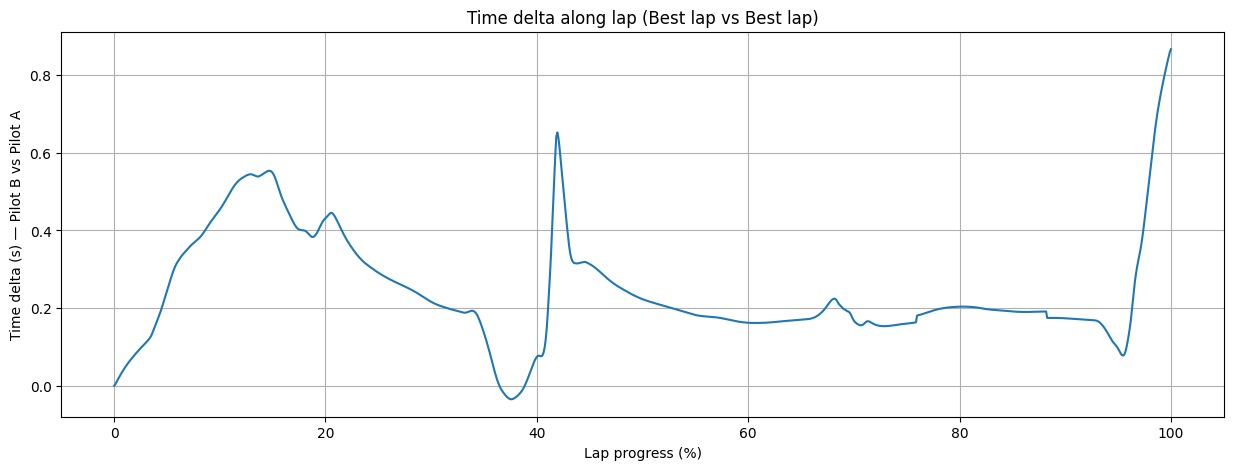

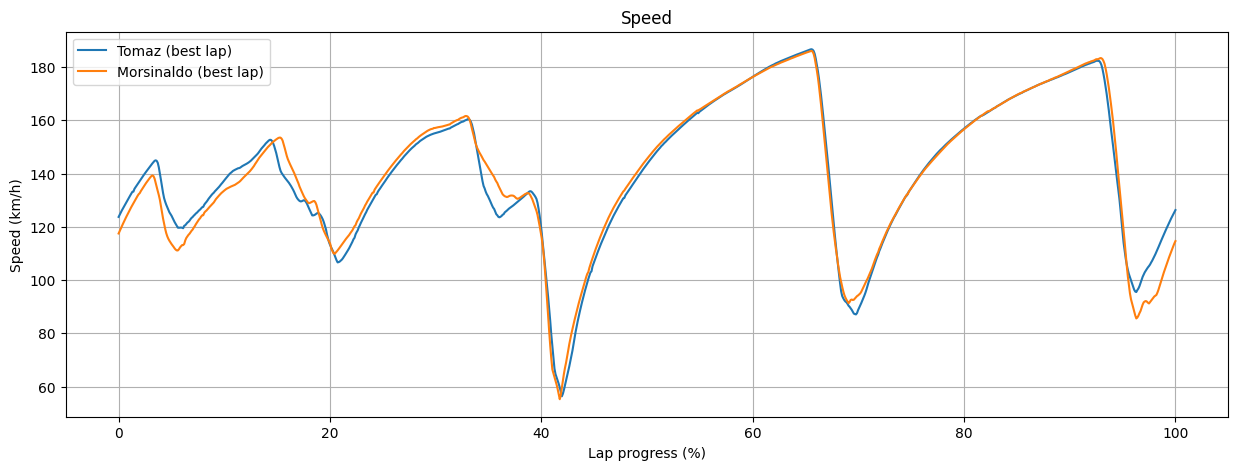

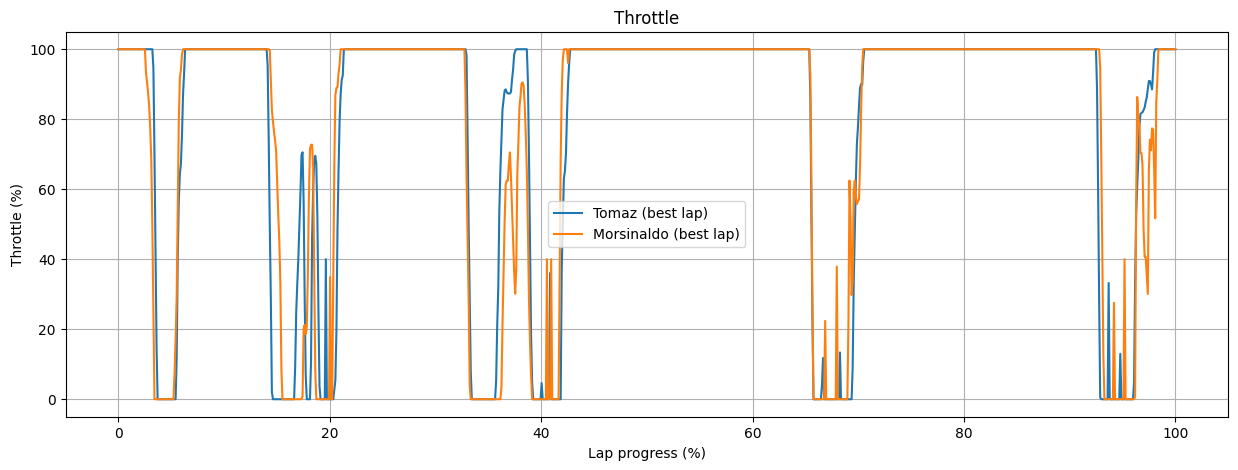

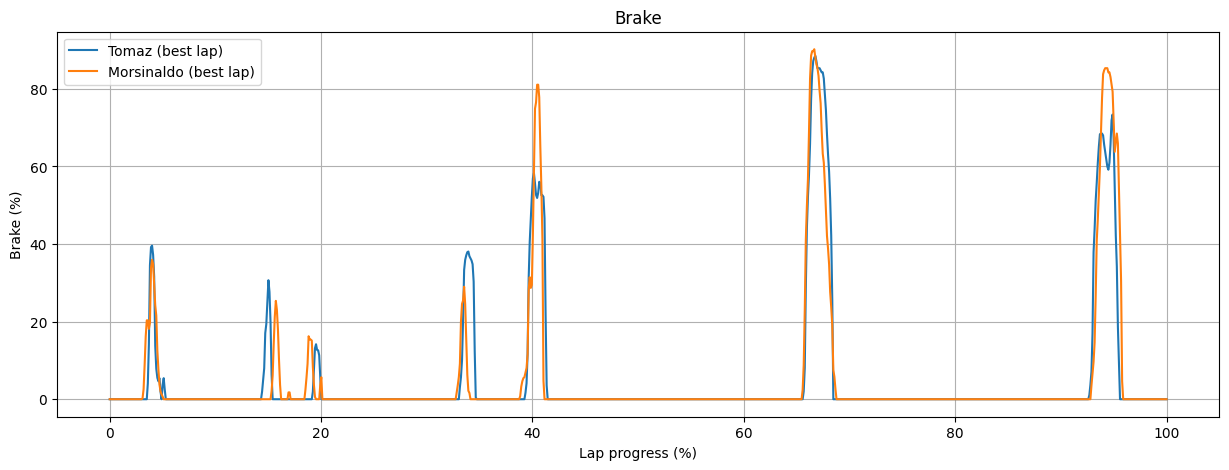

In [44]:
# --- Piloto A ---
lap_df_A = build_lap_validity_table(tomaz_df)
best_row_A = lap_df_A[lap_df_A["Valid"]].sort_values("LapTime_s").iloc[0]
best_lap_A = int(best_row_A["Lap"])

# --- Piloto B ---
lap_df_B = build_lap_validity_table(morsinaldo_df)
best_row_B = lap_df_B[lap_df_B["Valid"]].sort_values("LapTime_s").iloc[0]
best_lap_B = int(best_row_B["Lap"])

print(f"Piloto A - Best lap: {best_lap_A} ({format_laptime(best_row_A['LapTime_s'])})")
print(f"Piloto B - Best lap: {best_lap_B} ({format_laptime(best_row_B['LapTime_s'])})")

# Alinhamento por distância
grid = np.linspace(0.0, 1.0, BASE_GRID_LEN)

g_A = tomaz_df[tomaz_df["Lap"] == best_lap_A]
g_B = morsinaldo_df[morsinaldo_df["Lap"] == best_lap_B]

interp_A = align_lap_by_dist(g_A, grid)
interp_B = align_lap_by_dist(g_B, grid)


# Time-loss curve (target vs reference)
time_loss = interp_B["t_rel"] - interp_A["t_rel"]

plt.figure(figsize=(15, 5))
plt.plot(grid * 100.0, time_loss)
plt.xlabel("Lap progress (%)")
plt.ylabel("Time delta (s) — Pilot B vs Pilot A")
plt.title("Time delta along lap (Best lap vs Best lap)")
plt.grid(True)
plt.show()

def quick_plot(yA, yB, label, ylab):
    plt.figure(figsize=(15, 5))
    plt.plot(grid * 100.0, yA, label="Tomaz (best lap)")
    plt.plot(grid * 100.0, yB, label="Morsinaldo (best lap)")
    plt.xlabel("Lap progress (%)")
    plt.ylabel(ylab)
    plt.title(label)
    plt.legend()
    plt.grid(True)
    plt.show()

quick_plot(interp_A["speed"],    interp_B["speed"],    "Speed",    "Speed (km/h)")
quick_plot(interp_A["throttle"], interp_B["throttle"], "Throttle", "Throttle (%)")
quick_plot(interp_A["brake"],    interp_B["brake"],    "Brake",    "Brake (%)")




## 6. Sectorization and per-sector analysis

In the Charlotte track, we split the lap into **4 equal-length sectors** and compute per-sector **time, deltas, and simple signal differences**.


In [45]:
from typing import List

def sector_slices(n_points: int, n_sectors: int) -> List[slice]:
    """
    Divide um vetor de n_points em n_sectors segmentos contíguos,
    igualmente espaçados no domínio da distância normalizada.
    """
    edges = np.linspace(0, n_points - 1, n_sectors + 1).astype(int)
    slices = []

    for i in range(n_sectors):
        a = edges[i]
        b = edges[i + 1]

        # proteção contra setores vazios
        if b <= a:
            b = a + 1

        slices.append(slice(a, b + 1))

    return slices


def sector_analysis(
    lap_A: Dict[str, np.ndarray],
    lap_B: Dict[str, np.ndarray],
    n_sectors: int,
    label_A: str = "A",
    label_B: str = "B",
) -> pd.DataFrame:

    n = len(lap_A["t_rel"])
    slices = sector_slices(n, n_sectors)
    rows = []

    for i, sl_ in enumerate(slices, start=1):
        a, b = sl_.start, sl_.stop - 1
        sl = slice(a, b + 1)

        time_A = float(lap_A["t_rel"][b] - lap_A["t_rel"][a])
        time_B = float(lap_B["t_rel"][b] - lap_B["t_rel"][a])

        rows.append({
            "Sector": i,
            "Start_%": round(100 * a / (n - 1), 1),
            "End_%": round(100 * b / (n - 1), 1),

            f"Time_{label_A}_s": time_A,
            f"Time_{label_B}_s": time_B,
            "DeltaTime_s": time_B - time_A,

            "MeanSpeedDiff_kph": float(
                np.nanmean(lap_B["speed"][sl] - lap_A["speed"][sl])
            ),
            "MeanThrottleDiff_pct": float(
                np.nanmean(lap_B["throttle"][sl] - lap_A["throttle"][sl])
            ),
            "MeanBrakeDiff_pct": float(
                np.nanmean(lap_B["brake"][sl] - lap_A["brake"][sl])
            ),
        })

    return pd.DataFrame(rows)


In [46]:
N_SECTORS = 4

sectors_AB = sector_analysis(
    interp_A,
    interp_B,
    n_sectors=N_SECTORS,
    label_A="Tomaz",
    label_B="Morsinaldo",
)

sectors_AB


,Sector,Start_%,End_%,Time_Tomaz_s,Time_Morsinaldo_s,DeltaTime_s,MeanSpeedDiff_kph,MeanThrottleDiff_pct,MeanBrakeDiff_pct
0,1,0.0,24.9,24.810301,25.102594,0.292293,-1.360148,2.250065,0.208969
1,2,24.9,49.9,27.229584,27.160593,-0.068991,2.511432,-3.596355,-1.092942
2,3,49.9,75.0,22.674204,22.610774,-0.063430,0.402967,0.757757,-0.538444
3,4,75.0,100.0,22.019245,22.726039,0.706794,-1.589307,-0.379521,1.132794


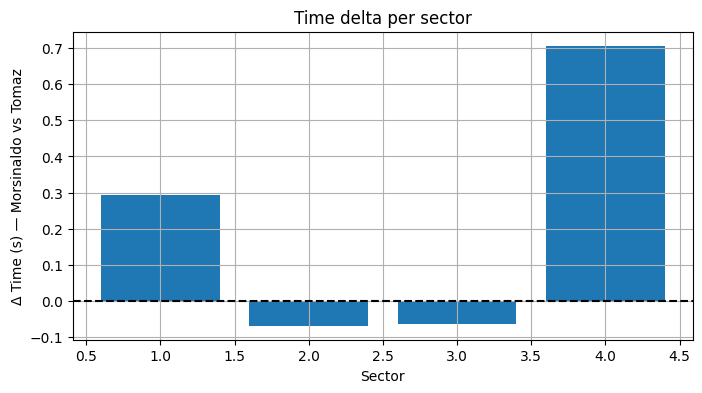

In [47]:
plt.figure(figsize=(8, 4))
plt.bar(
    sectors_AB["Sector"],
    sectors_AB["DeltaTime_s"],
)
plt.axhline(0, color="k", linestyle="--")
plt.xlabel("Sector")
plt.ylabel("Δ Time (s) — Morsinaldo vs Tomaz")
plt.title("Time delta per sector")
plt.grid(True)
plt.show()


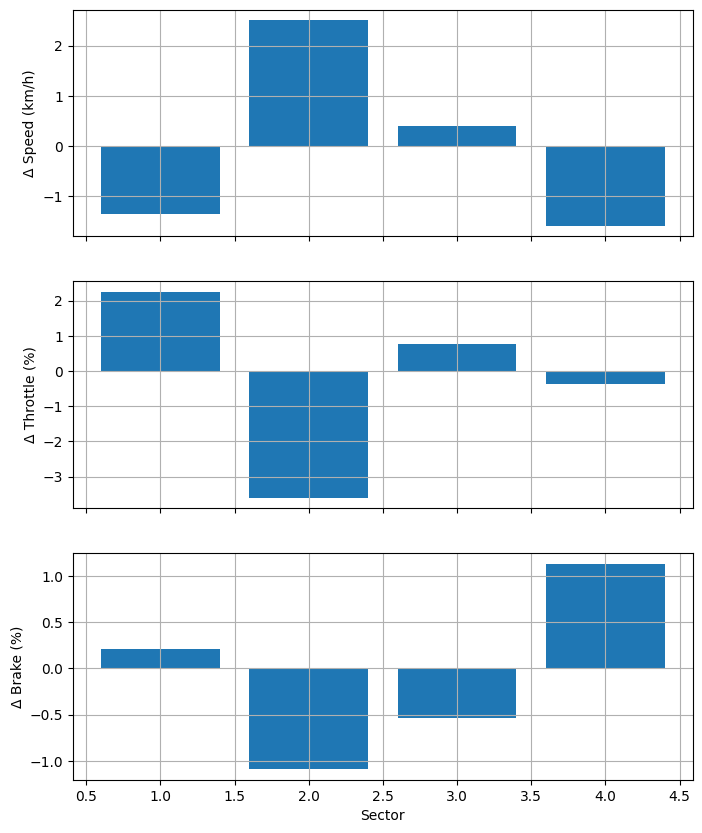

In [48]:
fig, ax = plt.subplots(3, 1, figsize=(8, 10), sharex=True)

ax[0].bar(sectors_AB["Sector"], sectors_AB["MeanSpeedDiff_kph"])
ax[0].set_ylabel("Δ Speed (km/h)")
ax[0].grid(True)

ax[1].bar(sectors_AB["Sector"], sectors_AB["MeanThrottleDiff_pct"])
ax[1].set_ylabel("Δ Throttle (%)")
ax[1].grid(True)

ax[2].bar(sectors_AB["Sector"], sectors_AB["MeanBrakeDiff_pct"])
ax[2].set_ylabel("Δ Brake (%)")
ax[2].set_xlabel("Sector")
ax[2].grid(True)

plt.show()



## New Heuristics



## Base Functions 

In [49]:
from scipy.signal import savgol_filter

## Calcular Derivadas
def compute_derivatives(sec: dict):
    t = sec["t_rel"]
    dt = np.mean(np.diff(t))

    brake = sec["brake"]
    throttle = sec["throttle"]
    steer = sec["steering"]
    yaw = sec["yaw_rate"]

    brake_rate = np.gradient(brake, dt)
    throttle_rate = np.gradient(throttle, dt)

    # Suavização (essencial)
    brake_rate = savgol_filter(brake_rate, 9, 3)
    throttle_rate = savgol_filter(throttle_rate, 9, 3)

    return brake_rate, throttle_rate

# Braking Heuristics
def braking_heuristics(sec: dict, brake_rate):
    d = {}

    brake_mask = sec["brake"] > 0.05  # 5%

    if np.any(brake_mask):
        d["BrakeRampRate"] = float(
            np.quantile(brake_rate[brake_mask], 0.95)
        )

        d["BrakeConsistency"] = float(
            np.var(brake_rate[brake_mask])
        )

        d["BrakeEfficiency"] = float(
            abs(np.min(sec["long_accel"][brake_mask])) /
            np.max(sec["brake"][brake_mask])
        )
    else:
        d["BrakeRampRate"] = 0.0
        d["BrakeConsistency"] = 0.0
        d["BrakeEfficiency"] = 0.0

    return d

#Rotation Heuristics:
#measure rotation quality, rotation vs minimum speed and steering input for yaw
def rotation_heuristics(sec: dict):
    d = {}

    speed = sec["speed"]
    yaw = sec["yaw_rate"]
    steer = sec["steering"]

    idx_vmin = np.argmin(speed)
    idx_mrp = np.argmax(np.abs(yaw))

    d["Vmin"] = float(speed[idx_vmin])
    d["Delta_MRP_Vmin"] = float(sec["t_rel"][idx_vmin] - sec["t_rel"][idx_mrp])

    if np.mean(np.abs(steer)) > 1e-3:
        d["RotationEfficiency"] = float(
            np.mean(np.abs(yaw)) / np.mean(np.abs(steer))
        )
    else:
        d["RotationEfficiency"] = 0.0

    return d


##acceleration heuristics
## measures throttle attack rate, smoothness and conflict with steering
def acceleration_heuristics(sec: dict, throttle_rate):
    d = {}

    throttle_mask = sec["throttle"] > 0.05

    if np.any(throttle_mask):
        d["ThrottleAttackRate"] = float(
            np.quantile(throttle_rate[throttle_mask], 0.95)
        )

        d["ThrottleSmoothness"] = float(
            1.0 / np.var(throttle_rate[throttle_mask])
        )

        d["ThrottleSteerConflict"] = float(
            np.mean(sec["throttle"] * np.abs(sec["steering"]))
        )
    else:
        d["ThrottleAttackRate"] = 0.0
        d["ThrottleSmoothness"] = 0.0
        d["ThrottleSteerConflict"] = 0.0

    return d

# Sector Heuristics
#transform sector data into heuristics
def sector_heuristics(sec_raw: dict) -> dict:
    sec = {
        "t_rel": sec_raw["t_rel"],
        "speed": sec_raw["speed"],
        "brake": sec_raw["brake"],
        "throttle": sec_raw["throttle"],
        "steering": sec_raw["SteeringWheelAngle"],
        "yaw_rate": sec_raw["YawRate"],
        "long_accel": sec_raw["LongAccel"],
    }

    brake_rate, throttle_rate = compute_derivatives(sec)

    h = {}
    h.update(braking_heuristics(sec, brake_rate))
    h.update(rotation_heuristics(sec))
    h.update(acceleration_heuristics(sec, throttle_rate))
    return h

#compute heuristics for all sectors for one driver
#interp = saída do align_lap_by_dist
#sector_heuristics = aquela função grande que já criamos
#saída = 1 linha por setor

def compute_sector_heuristics(
    interp: dict,
    n_sectors: int
) -> pd.DataFrame:

    n = len(interp["t_rel"])
    slices = sector_slices(n, n_sectors)

    rows = []

    for sid, sl in enumerate(slices, start=1):
        sec_raw = {k: v[sl] for k, v in interp.items()}

        h = sector_heuristics(sec_raw)

        h_row = {"Sector": sid}
        h_row.update(h)
        rows.append(h_row)

    return pd.DataFrame(rows)




## Driver A - Heuristics

In [50]:
heur_A = compute_sector_heuristics(
    interp=interp_A,
    n_sectors=N_SECTORS
)

heur_A.insert(0, "Pilot", "A")
heur_A


,Pilot,Sector,BrakeRampRate,BrakeConsistency,BrakeEfficiency,Vmin,Delta_MRP_Vmin,RotationEfficiency,ThrottleAttackRate,ThrottleSmoothness,ThrottleSteerConflict
0,A,1,86.263929,2407.541421,0.177751,106.637928,0.120004,0.457984,121.046493,0.000228,34.283182
1,A,2,89.126640,3266.768658,0.186627,56.374464,-1.511929,0.572464,63.712143,0.000481,25.146625
2,A,3,128.953427,6166.985793,0.160412,87.107886,0.298246,0.826539,21.755823,0.000699,14.306291
3,A,4,114.089622,5423.285560,0.168989,95.509100,-1.421082,0.912103,19.909506,0.000637,19.668379


## Driver B - Heuristics

In [51]:
heur_B = compute_sector_heuristics(
    interp=interp_B,
    n_sectors=N_SECTORS
)

heur_B.insert(0, "Pilot", "B")
heur_B


,Pilot,Sector,BrakeRampRate,BrakeConsistency,BrakeEfficiency,Vmin,Delta_MRP_Vmin,RotationEfficiency,ThrottleAttackRate,ThrottleSmoothness,ThrottleSteerConflict
0,B,1,45.441951,1248.157627,0.183431,109.836902,0.118373,0.654697,114.676881,0.000332,25.103583
1,B,2,90.824711,4263.990809,0.145049,55.275488,-0.556822,0.551465,86.995543,0.000439,23.815360
2,B,3,131.396266,5007.495535,0.157668,91.333262,0.695214,0.648566,24.170509,0.000840,20.465968
3,B,4,98.545344,5413.810333,0.163635,85.599167,-1.631291,0.836354,50.816689,0.000503,19.244763


# Driver Feedback Rules

Esta seção implementa um pipeline de *coaching* baseado em regras para comparar duas voltas (A como referência e B como piloto avaliado) **por setor**. O objetivo é transformar séries temporais brutas (speed, brake, throttle, steering, yaw, RPM e gear) em:

1. **Estados interpretáveis** ao longo da volta (BRAKING, CORNER, EXIT, STRAIGHT).
2. **Métricas agregadas** por (Setor, Estado), permitindo comparação entre A e B.
3. **Deltas (B − A)** por métrica, para localizar onde o piloto perde tempo.
4. **Regras de feedback** que geram dicas curtas e acionáveis, com contexto de *onde* e *que tipo de curva* é.

A ideia central é reduzir a complexidade do sinal contínuo para um conjunto pequeno de indicadores por fase de pilotagem, o que facilita feedback para pilotos iniciantes e permite evolução incremental das regras ao longo do tempo.

## Utilitários de índice (primeiro e último evento)

Antes de extrair eventos (por exemplo, início e fim de frenagem), usamos dois utilitários simples:

- `_first_idx(mask)`: retorna o primeiro índice onde uma condição booleana é verdadeira.
- `_last_idx(mask)`: retorna o último índice onde uma condição booleana é verdadeira.

Essas funções são úteis para detectar “janelas de evento” em sinais contínuos, como:
- intervalo em que o freio está acima de um threshold;
- intervalo em que o throttle está acima de um threshold após o ápice;
- overlap entre freio e acelerador.

Esse padrão evita lógica repetida e padroniza o comportamento quando o evento não existe (retorna `None`).

In [52]:
def _first_idx(mask: np.ndarray):
    idx = np.flatnonzero(mask)
    return int(idx[0]) if idx.size else None

def _last_idx(mask: np.ndarray):
    idx = np.flatnonzero(mask)
    return int(idx[-1]) if idx.size else None

## Rotulagem de estados (BRAKING, CORNER, EXIT, STRAIGHT)

Para gerar dicas por fase, primeiro precisamos “entender” o que o carro está fazendo ao longo do tempo. A função `label_state_df` recebe um DataFrame com sinais normalizados em percentual e devolve um vetor de estados:

- **BRAKING**: freio acima do threshold.
- **CORNER**: lateralidade alta (steering e opcionalmente yaw), independentemente do throttle.
- **EXIT**: throttle alto **e** lateralidade baixa (carro já está alinhado).
- **STRAIGHT**: restante.

A ordem de prioridade é importante:

1. **BRAKING tem prioridade máxima**, porque durante a frenagem o comportamento é dominado pela desaceleração e estabilidade.
2. **CORNER vem em seguida**, para capturar curvas “flat-out” (throttle alto com volante carregado).
3. **EXIT só ocorre quando o carro está alinhado**, ou seja, throttle alto com baixa lateralidade, representando retomada na saída.
4. O que sobra vira **STRAIGHT**.

Esse esquema evita confundir “aceleração em curva” com “saída da curva” e produz estados mais coerentes para coaching.

In [53]:
def label_state_df(
    g: pd.DataFrame,
    brake_th: float = 20.0,
    throttle_th: float = 60.0,
    steer_th: float = 5.0,
    yaw_th: float = None,   # ex: 0.08 se você quiser usar yaw
):
    """
    Retorna rótulos: BRAKING / CORNER / EXIT / STRAIGHT

    - BRAKING: brake > brake_th
    - CORNER: lateralidade alta (steer/yaw), independentemente de throttle
    - EXIT: throttle alto e lateralidade baixa
    - STRAIGHT: resto

    Mantém o mesmo nome/assinatura para substituir no notebook.
    """
    brake = g["Brake_Pct"].to_numpy()
    throttle = g["Throttle_Pct"].to_numpy()

    steer = g["SteeringWheelAngle"].to_numpy() if "SteeringWheelAngle" in g.columns else None
    yaw = g["YawRate"].to_numpy() if "YawRate" in g.columns else None

    n = len(g)
    state = np.array(["STRAIGHT"] * n, dtype=object)

    # 1) BRAKING (prioridade máxima)
    braking = brake > brake_th
    state[braking] = "BRAKING"

    # 2) lateralidade alta => CORNER (mesmo com throttle alto)
    lateral = np.zeros(n, dtype=bool)
    if steer is not None:
        lateral |= (np.abs(steer) > steer_th)
    if yaw_th is not None and yaw is not None:
        lateral |= (np.abs(yaw) > yaw_th)

    corner = lateral & (~braking)
    state[corner] = "CORNER"

    # 3) EXIT: throttle alto e lateralidade baixa (a curva já acabou)
    exit_mask = (throttle > throttle_th) & (~braking) & (~lateral)
    state[exit_mask] = "EXIT"

    return pd.Series(state, index=g.index, name="State")

## Agregação por (Setor, Estado)

Após rotular cada amostra com um estado, a função `summarize_by_sector_and_state` transforma a volta em uma tabela agregada. O procedimento é:

1. **Divide a volta em setores** usando `LapDistPct` em intervalos uniformes (ex.: 4 setores por quartis).
2. **Cria um DataFrame temporário (`gtmp`)** com as colunas exigidas por `label_state_df`, reaproveitando a mesma assinatura.
3. **Gera o vetor de estados** para cada amostra.
4. **Segmenta trechos contínuos** com o mesmo estado (runs).  
   - Isso evita misturar momentos diferentes da pilotagem dentro do mesmo estado.
   - `min_len` remove segmentos muito curtos, que tendem a ser ruído de limiar.
5. Para cada segmento válido, calcula métricas relevantes e monta linhas “por trecho”.
6. Por fim, agrega (groupby) por **(Sector, State)** para obter uma tabela compacta por volta.

O resultado é uma tabela que representa “como foi a pilotagem em cada setor e em cada fase”, pronta para comparação entre A e B.

In [54]:
def summarize_by_sector_and_state(
    interp: dict,
    n_sectors: int = 4,
    min_len: int = 25
):
    """
    Estados (via label_state_df):
      - CORNER não depende de throttle (curva flat-out vira CORNER)
      - EXIT só quando lateralidade está baixa

    Métricas para coaching:
      - LiftFrac: throttle parcial (10..60) sem freio (<5)
      - CoastFrac: sem throttle (<10) e sem freio (<5)
      - BrakeLen: duração do trecho de frenagem (em amostras)
      - BrakePeak_Lap: LapDistPct do pico de freio
      - ThrottleOn_*: posição/speed/RPM/gear no instante de throttle-on
      - EntrySpeed: velocidade no final do trecho BRAKING (proxy de speed de turn-in/entrada)
    """
    lap = interp["LapDistPct"]
    speed = interp["speed"]
    brake = interp["brake"]
    throttle = interp["throttle"]

    steer = interp.get("SteeringWheelAngle", None)
    yaw = interp.get("YawRate", None)
    rpm = interp.get("RPM", None)
    gear = interp.get("Gear", None)

    edges = np.linspace(0.0, 1.0, n_sectors + 1)
    sector = np.clip(np.digitize(lap, edges, right=True), 1, n_sectors)

    gtmp = pd.DataFrame({
        "Brake_Pct": brake,
        "Throttle_Pct": throttle,
        "SteeringWheelAngle": steer if steer is not None else np.zeros_like(brake),
        "YawRate": yaw if yaw is not None else np.zeros_like(brake),
    })

    state = label_state_df(
        gtmp,
        brake_th=20.0,
        throttle_th=60.0,
        steer_th=5.0,
        yaw_th=None,
    ).to_numpy()

    def segment_runs(vals: np.ndarray):
        runs = []
        n = len(vals)
        i = 0
        while i < n:
            j = i + 1
            while j < n and vals[j] == vals[i]:
                j += 1
            runs.append((i, j, vals[i]))
            i = j
        return runs

    def _mode_int(arr):
        arr = arr[~np.isnan(arr)]
        if len(arr) == 0:
            return np.nan
        c = Counter(arr.astype(int).tolist())
        return float(c.most_common(1)[0][0])

    rows = []
    runs = segment_runs(state)

    for a, b, lab in runs:
        if (b - a) < min_len:
            continue

        sid = int(Counter(sector[a:b].tolist()).most_common(1)[0][0])
        lap_mid = float(np.median(lap[a:b]))

        coast_mask = (brake[a:b] < 5.0) & (throttle[a:b] < 10.0)
        lift_mask  = (brake[a:b] < 5.0) & (throttle[a:b] >= 10.0) & (throttle[a:b] <= 60.0)

        row = {
            "Sector": sid,
            "State": lab,
            "LapMid": lap_mid,
            "Len": int(b - a),

            "SpeedMean": float(np.mean(speed[a:b])),
            "SpeedEnd": float(speed[b-1]),
            "ThrottleMean": float(np.mean(throttle[a:b])),

            "CoastFrac": float(np.mean(coast_mask)),
            "LiftFrac": float(np.mean(lift_mask)),
        }

        # =========================
        # BRAKING
        # =========================
        if lab == "BRAKING":
            row["BrakeMean"] = float(np.mean(brake[a:b]))
            row["BrakePeak"] = float(np.max(brake[a:b]))
            row["BrakeLen"]  = float(b - a)
            row["Vmin"]      = float(np.min(speed[a:b]))

            peak_i = a + int(np.argmax(brake[a:b]))
            row["BrakePeak_Lap"] = float(lap[peak_i])

            # NOVO: EntrySpeed = speed no final do trecho BRAKING (proxy de turn-in)
            row["EntrySpeed"] = float(speed[b-1])

        else:
            row["BrakeMean"] = np.nan
            row["BrakePeak"] = np.nan
            row["BrakeLen"]  = np.nan
            row["BrakePeak_Lap"] = np.nan
            row["EntrySpeed"] = np.nan

        # =========================
        # CORNER
        # =========================
        if lab == "CORNER":
            row["Vmin"] = float(np.min(speed[a:b]))

            if steer is not None:
                row["SteerRMS"] = float(np.sqrt(np.mean((steer[a:b])**2)))
            else:
                row["SteerRMS"] = np.nan

            if yaw is not None and steer is not None:
                denom = np.mean(np.abs(steer[a:b])) + 1e-6
                row["YawSteerEff"] = float(np.mean(np.abs(yaw[a:b])) / denom)
            else:
                row["YawSteerEff"] = np.nan
        else:
            row.setdefault("Vmin", np.nan)
            row.setdefault("SteerRMS", np.nan)
            row.setdefault("YawSteerEff", np.nan)

        # =========================
        # EXIT (throttle-on)
        # =========================
        if lab == "EXIT":
            thr_mask = (throttle[a:b] > 60.0)
            if np.any(thr_mask):
                thr_on_local = int(np.flatnonzero(thr_mask)[0])
            else:
                thr_on_local = 0

            idx = a + thr_on_local
            idx = min(max(idx, a), b - 1)

            row["ThrottleOn_Lap"] = float(lap[idx])
            row["ThrottleOn_Speed"] = float(speed[idx])

            if rpm is not None:
                row["RPMAtThrottleOn"] = float(rpm[idx])
                row["RPMMean"] = float(np.mean(rpm[a:b]))
            else:
                row["RPMAtThrottleOn"] = np.nan
                row["RPMMean"] = np.nan

            if gear is not None:
                row["GearAtThrottleOn"] = float(gear[idx])
                row["GearMode"] = _mode_int(gear[a:b].astype(float))
            else:
                row["GearAtThrottleOn"] = np.nan
                row["GearMode"] = np.nan
        else:
            row["ThrottleOn_Lap"] = np.nan
            row["ThrottleOn_Speed"] = np.nan
            row["RPMAtThrottleOn"] = np.nan
            row["RPMMean"] = np.nan
            row["GearAtThrottleOn"] = np.nan
            row["GearMode"] = np.nan

        rows.append(row)

    seg_df = pd.DataFrame(rows)
    if seg_df.empty:
        return seg_df

    agg = (seg_df
           .groupby(["Sector", "State"], as_index=False)
           .agg({
               "LapMid": "median",
               "Len": "sum",

               "SpeedMean": "mean",
               "SpeedEnd": "mean",

               "BrakeMean": "mean",
               "BrakePeak": "max",
               "BrakeLen": "sum",
               "BrakePeak_Lap": "median",
               "EntrySpeed": "median",   # NOVO

               "ThrottleMean": "mean",
               "Vmin": "min",

               "SteerRMS": "mean",
               "YawSteerEff": "mean",

               "CoastFrac": "mean",
               "LiftFrac": "mean",

               "ThrottleOn_Lap": "median",
               "ThrottleOn_Speed": "median",
               "RPMAtThrottleOn": "median",
               "RPMMean": "mean",
               "GearAtThrottleOn": "median",
               "GearMode": "median",
           }))

    return agg

## Geração das tabelas agregadas (A e B)

Com `summarize_by_sector_and_state`, geramos uma tabela por volta:

- `A_seg`: volta de referência (lap A)
- `B_seg`: volta do piloto avaliado (lap B)

Cada tabela contém linhas por (Setor, Estado) e colunas com as métricas agregadas.  
Essas tabelas são a base do passo seguinte: comparar A vs B e calcular deltas.

In [55]:
A_seg = summarize_by_sector_and_state(interp_A, n_sectors=4)
B_seg = summarize_by_sector_and_state(interp_B, n_sectors=4)

## Comparação A vs B por estado e setor (deltas B − A)

A função `compare_seg_tables` faz o merge das tabelas agregadas por:

- `Sector`
- `State`

e cria colunas `Δ_*` calculadas como **B − A** para cada métrica existente.

Por que usar deltas?

- As métricas absolutas variam por carro, setup e pista.
- O delta foca no que importa para coaching: **o que mudou em relação à referência**.
- Os deltas viram “features” de regras: exemplos
  - Δ_EntrySpeed negativo → piloto entra mais lento.
  - Δ_ThrottleOn_Speed negativo → piloto retoma com velocidade menor.
  - Δ_CoastFrac positivo → piloto está “tirando pé” mais tempo.

Além das métricas agregadas, também existe espaço para incluir colunas do pipeline 1 (como BrakeRampRate etc.), quando elas estiverem disponíveis em `A_seg` e `B_seg`.

In [56]:
def compare_seg_tables(A_seg: pd.DataFrame, B_seg: pd.DataFrame):
    m = A_seg.merge(B_seg, on=["Sector", "State"], suffixes=("_A","_B"))
    # deltas B-A
    for col in [
        "Vmin","SteerRMS","YawSteerEff",
        "BrakePeak","BrakeMean","BrakeLen","BrakePeak_Lap",
        "ThrottleMean","SpeedEnd","SpeedMean",
        "RPMAtThrottleOn","GearAtThrottleOn","ThrottleOn_Lap",
        "CoastFrac","LiftFrac", "EntrySpeed",

        # novas (pipeline 1)
        "BrakeRampRate","BrakeConsistency","BrakeEfficiency",
        "RotationEfficiency","Delta_MRP_Vmin",
        "ThrottleAttackRate","ThrottleSmoothness","ThrottleSteerConflict",
    ]:
        if f"{col}_A" in m.columns and f"{col}_B" in m.columns:
            m[f"Δ_{col}"] = m[f"{col}_B"] - m[f"{col}_A"]

    # localização
    m["LapMid_B"] = m["LapMid_B"]
    return m

seg_cmp = compare_seg_tables(A_seg, B_seg)
seg_cmp

,Sector,State,LapMid_A,Len_A,SpeedMean_A,SpeedEnd_A,BrakeMean_A,BrakePeak_A,BrakeLen_A,BrakePeak_Lap_A,...,Δ_BrakePeak_Lap,Δ_ThrottleMean,Δ_SpeedEnd,Δ_SpeedMean,Δ_RPMAtThrottleOn,Δ_GearAtThrottleOn,Δ_ThrottleOn_Lap,Δ_CoastFrac,Δ_LiftFrac,Δ_EntrySpeed
0,1,EXIT,0.058559,120,135.596117,148.592168,NaN,NaN,0.0,NaN,...,NaN,-1.272035,-2.531975,-4.142211,-361.020177,0.0,-0.000501,0.0,0.0,NaN
1,2,EXIT,0.322072,151,134.708209,146.792731,NaN,NaN,0.0,NaN,...,NaN,3.589527,14.770494,7.565536,373.555890,-0.5,-0.080581,0.0,0.0,NaN
2,3,BRAKING,0.671171,26,142.824021,95.779358,69.833634,88.528611,26.0,0.667668,...,-0.001001,1.190488,5.386173,0.755042,NaN,NaN,NaN,0.0,0.0,5.386173
3,3,EXIT,0.538038,234,149.876537,186.588396,NaN,NaN,0.0,NaN,...,NaN,0.227924,-0.538355,0.450540,-53.999788,0.0,-0.003003,0.0,0.0,NaN
4,4,EXIT,0.897147,267,131.917674,154.297119,NaN,NaN,0.0,NaN,...,NaN,3.650003,28.989826,22.436825,-107.628824,0.0,-0.129129,0.0,0.0,NaN


## Extração de eventos por setor (apex e timings)

Além da visão por estado, usamos um segundo bloco para extrair eventos “pontuais” dentro de cada setor, como:

- **Vmin**: proxy do ápice (mínima velocidade do setor).
- **brake_on / brake_off**: início/fim da janela de freio acima do threshold.
- **throttle_on**: primeiro ponto de throttle acima do threshold após o ápice.

Com esses eventos calculamos métricas temporais relativas ao ápice (Vmin), como:

- **brake_lead_vs_vmin**: quanto antes do ápice o freio começa.
- **brake_release_vs_vmin**: quanto depois/antes do ápice o freio termina.
- **throttle_delay_vs_vmin**: quanto tempo após o ápice o throttle volta.

Esse conjunto é útil para regras mais “cinemáticas” (timing), complementando as métricas agregadas por estado.

In [57]:
def sector_events(sec, brake_th=0.05, throttle_th=0.05):
    t = sec["t_rel"]
    speed = sec["speed"]
    brake = sec["brake"]
    throttle = sec["throttle"]
    lap = sec["LapDistPct"]

    idx_vmin = int(np.argmin(speed))

    # brake_on/off: primeiro e último acima do threshold (dentro do setor)
    brake_mask = brake > brake_th
    idx_brake_on = _first_idx(brake_mask)
    idx_brake_off = _last_idx(brake_mask)

    # throttle_on: primeiro throttle após o vmin
    post = np.arange(len(t)) >= idx_vmin
    idx_throttle_on = _first_idx((throttle > throttle_th) & post)

    ev = {
        "t_vmin": float(t[idx_vmin]),
        "vmin": float(speed[idx_vmin]),
        "lap_vmin": float(lap[idx_vmin]) if lap is not None else None,

        "t_brake_on": float(t[idx_brake_on]) if idx_brake_on is not None else None,
        "t_brake_off": float(t[idx_brake_off]) if idx_brake_off is not None else None,

        "t_throttle_on": float(t[idx_throttle_on]) if idx_throttle_on is not None else None,
    }

    # relações ao apex (Vmin)
    ev["brake_lead_vs_vmin"] = (ev["t_vmin"] - ev["t_brake_on"]) if ev["t_brake_on"] is not None else None
    ev["throttle_delay_vs_vmin"] = (ev["t_throttle_on"] - ev["t_vmin"]) if ev["t_throttle_on"] is not None else None
    ev["brake_release_vs_vmin"] = (ev["t_brake_off"] - ev["t_vmin"]) if ev["t_brake_off"] is not None else None

    return ev

def compute_sector_events_table(interp, n_sectors):
    n = len(interp["t_rel"])
    slices = sector_slices(n, n_sectors)

    rows = []
    for sid, sl in enumerate(slices, start=1):
        sec = {k: v[sl] for k, v in interp.items()}
        sec["LapDistPct"] = interp["LapDistPct"][sl]
        
        ev = sector_events(sec)

        row = {"Sector": sid, **ev}
        rows.append(row)

    return pd.DataFrame(rows)

## Tabela de eventos por setor

`compute_sector_events_table` percorre todos os setores e aplica `sector_events` para cada slice da volta.

O resultado é uma tabela por volta (A e B) com:
- posição do ápice (lap_vmin),
- timings (t_brake_on/off, t_throttle_on),
- métricas relativas ao ápice.

Depois, `compare_sector_tables` faz o merge A vs B por setor e produz `Δ_*` das métricas principais.

Essa tabela é usada para detectar padrões de “timing”, como:
- frear cedo demais,
- soltar freio tarde demais,
- voltar ao throttle tarde demais.

In [58]:
def compare_sector_tables(evA, evB, sectors_AB):
    m = evA.merge(evB, on="Sector", suffixes=("_A", "_B"))
    m = m.merge(sectors_AB[["Sector", "DeltaTime_s"]], on="Sector", how="left")

    # deltas = B - A
    for c in ["vmin", "brake_lead_vs_vmin", "throttle_delay_vs_vmin", "brake_release_vs_vmin"]:
        m[f"Δ_{c}"] = m[f"{c}_B"] - m[f"{c}_A"]

    return m

evA = compute_sector_events_table(interp_A, N_SECTORS)
evB = compute_sector_events_table(interp_B, N_SECTORS)
ev_cmp = compare_sector_tables(evA, evB, sectors_AB)
ev_cmp

,Sector,t_vmin_A,vmin_A,lap_vmin_A,t_brake_on_A,t_brake_off_A,t_throttle_on_A,brake_lead_vs_vmin_A,throttle_delay_vs_vmin_A,brake_release_vs_vmin_A,...,t_brake_off_B,t_throttle_on_B,brake_lead_vs_vmin_B,throttle_delay_vs_vmin_B,brake_release_vs_vmin_B,DeltaTime_s,Δ_vmin,Δ_brake_lead_vs_vmin,Δ_throttle_delay_vs_vmin,Δ_brake_release_vs_vmin
0,1,20.230933,106.637928,0.207207,3.462917,19.307217,20.230933,16.768017,0.0,-0.923716,...,19.850664,20.319869,17.195740,0.0,-0.469205,0.292293,3.198974,0.427723,0.0,0.454511
1,2,41.765629,56.374464,0.419419,31.893556,40.466783,41.765629,9.872073,0.0,-1.298846,...,40.139278,41.861094,10.021851,0.0,-1.721816,-0.068991,-1.098977,0.149778,0.0,-0.422970
2,3,68.696897,87.107886,0.697698,64.195964,66.684832,68.696897,4.500933,0.0,-2.012065,...,67.308157,67.866888,3.569487,0.0,-0.558731,-0.063430,4.225376,-0.931445,0.0,1.453333
3,4,92.359837,95.509100,0.962963,88.788517,91.325946,92.359837,3.571320,0.0,-1.033891,...,91.807271,92.552543,3.453631,0.0,-0.745272,0.706794,-9.909933,-0.117689,0.0,0.288620


## Contexto textual da dica: posição no setor e tipo de curva (proxy)

Para que a mensagem de coaching seja mais compreensível, adicionamos um prefixo com:

1. **Setor** (S1..Sn).
2. **Posição no setor**: início, meio ou fim (derivado de LapDistPct relativo ao intervalo do setor).
3. **Tipo de curva**: reta/aberta, média ou fechada.

O tipo de curva é estimado por um proxy geométrico:
- mede picos locais de yaw e steer em uma janela “à frente” do evento,
- transforma o valor em percentil dentro de uma distribuição construída ao longo da volta,
- classifica em níveis (aberta/média/fechada).

A motivação é prática: pilotos iniciantes entendem melhor “onde” e “que tipo de curva” do que apenas uma métrica abstrata.

In [59]:
def sector_position_label(lap_pct: float, sector_id: int, n_sectors: int = 4) -> str:
    """Converte LapDistPct em 'início/meio/fim' dentro do setor."""
    s0 = (sector_id - 1) / n_sectors
    s1 = sector_id / n_sectors
    if not np.isfinite(lap_pct):
        return "posição indefinida"
    u = (lap_pct - s0) / (s1 - s0 + 1e-12)  # 0..1 dentro do setor
    if u < 0.33:
        return "início do setor"
    if u < 0.66:
        return "meio do setor"
    return "fim do setor"

def peak_proxy_ahead(interp: dict, lap_pct: float, ahead_pct: float = 0.02, window_pct: float = 0.004):
    """
    Retorna o pico de curvatura e pico de steer em uma janela [lap, lap+ahead].
    - ahead_pct=0.02 => olha até +2% da volta (ótimo para pegar a curva depois da frenagem)
    """
    lap = interp.get("LapDistPct", None)
    if lap is None or not np.isfinite(lap_pct):
        return np.nan, np.nan

    lap = np.asarray(lap)

    # máscara lookahead (sem wrap-around por enquanto; suficiente pra dentro do setor)
    m = (lap >= lap_pct - window_pct) & (lap <= lap_pct + ahead_pct)
    if not np.any(m):
        return np.nan, np.nan

    speed = np.asarray(interp.get("speed", np.nan*np.ones_like(lap)))

    # yaw proxy
    yaw_peak = np.nan
    if interp.get("YawRate", None) is not None:
        yaw = np.asarray(interp["YawRate"])
        v_ms = speed[m] / 3.6
        valid = (v_ms > 2.0) & np.isfinite(yaw[m]) & np.isfinite(v_ms)
        if np.any(valid):
            vals = np.abs(yaw[m][valid]) / (v_ms[valid] + 1e-6)
            yaw_peak = float(np.nanmax(vals))

    # steer proxy
    steer_peak = np.nan
    if interp.get("SteeringWheelAngle", None) is not None:
        steer = np.asarray(interp["SteeringWheelAngle"])
        vals = np.abs(steer[m])
        vals = vals[np.isfinite(vals)]
        if vals.size:
            steer_peak = float(np.nanmax(vals))

    return yaw_peak, steer_peak

def build_proxy_distributions(interp: dict):
    sample_pcts = np.linspace(0.01, 0.99, 250)
    yaw_vals, st_vals = [], []
    for p in sample_pcts:
        ypk, spk = peak_proxy_ahead(interp, p, ahead_pct=0.02, window_pct=0.003)
        if np.isfinite(ypk): yaw_vals.append(ypk)
        if np.isfinite(spk): st_vals.append(spk)
    return np.sort(np.asarray(yaw_vals)), np.sort(np.asarray(st_vals))

def percentile_rank(sorted_vals: np.ndarray, x: float) -> float:
    if sorted_vals.size == 0 or not np.isfinite(x):
        return np.nan
    return float(np.searchsorted(sorted_vals, x, side="right") / sorted_vals.size)

def label_from_percentile(p: float) -> str:
    if not np.isfinite(p):
        return "geometria indefinida"
    if p >= 0.80:
        return "curva fechada"
    if p >= 0.55:
        return "curva média"
    return "reta ou curva aberta"

def pick_event_lappct(row: pd.Series, state: str) -> float:
    """Escolhe o LapPct onde a dica realmente acontece (âncora do texto)."""
    if state == "EXIT":
        v = row.get("ThrottleOn_Lap_B", np.nan)
        if np.isfinite(v):
            return float(v)
    if state == "BRAKING":
        v = row.get("BrakePeak_Lap_B", np.nan)
        if np.isfinite(v):
            return float(v)
    return float(row.get("LapMid_B", np.nan))


def pick_geometry_lappct(row_dict: dict, state: str, rule_id: str = "") -> float:
    """
    Onde medir a geometria:
    - BRAKING: olhar adiante do pico de freio (pegar curva após a frenagem)
    - EXIT:
        * se a dica é de 'saída limitada' (linha/ápice), medir mais perto do miolo (LapMid)
        * se a dica é de gear/rpm, medir perto do throttle-on
    """
    if state == "BRAKING":
        p = row_dict.get("BrakePeak_Lap_B", np.nan)
        return float(p) if np.isfinite(p) else float(row_dict.get("LapMid_B", np.nan))

    if state == "EXIT":
        # para dicas de saída, a curva relevante é perto do throttle-on (saída da curva)
        p = row_dict.get("ThrottleOn_Lap_B", np.nan)
        if np.isfinite(p):
            # um pouco ANTES do throttle-on costuma pegar mais "raio" (ainda com volante)
            return float(p - 0.003)
        return float(row_dict.get("LapMid_B", np.nan))

    return float(row_dict.get("LapMid_B", np.nan))

def format_tip_prefix(interp_B: dict,
                      sector_id: int,
                      lap_event: float,
                      lap_geom: float,
                      dist_yaw: np.ndarray,
                      dist_steer: np.ndarray,
                      tip_state: str,
                      n_sectors: int = 4) -> str:

    pos = sector_position_label(lap_event, sector_id, n_sectors=n_sectors)

    # Para BRAKING/EXIT, o lookahead é essencial. Para outros, pode ser menor.
    ahead = 0.03 if tip_state == "BRAKING" else (0.02 if tip_state == "EXIT" else 0.01)

    ypk, spk = peak_proxy_ahead(interp_B, lap_geom, ahead_pct=ahead, window_pct=0.003)

    py = percentile_rank(dist_yaw, ypk)
    ps = percentile_rank(dist_steer, spk)

    # decide pelo sinal mais confiável (o que der percentil válido e maior)
    cand = [(py, "yaw"), (ps, "steer")]
    cand = [(p, src) for (p, src) in cand if np.isfinite(p)]
    if not cand:
        ctype = "geometria indefinida"
    else:
        p_best, _ = max(cand, key=lambda t: t[0])
        ctype = label_from_percentile(p_best)

    return f"Setor {sector_id} · {pos} · {ctype}: "


## Regras de coaching (`DRIVING_RULES`)

As regras são declaradas como uma lista de dicionários com:

- `id`: identificador único.
- `state`: estado ao qual a regra se aplica (BRAKING/CORNER/EXIT).
- `condition(A, B)`: lógica booleana que decide se a dica deve disparar.
- `message` ou `message_fn`: texto fixo ou texto dinâmico.
- `priority`: importância relativa para ordenar dicas.
- `group` (opcional): agrupamento para evitar múltiplas dicas redundantes sobre o mesmo fenômeno.

Exemplo de regra adicionada para piloto iniciante:
- **ENTRY_SPEED_TOO_LOW**: quando B entra significativamente mais lento que A (EntrySpeed).

Isso gera dicas com números concretos (km/h), que tendem a ser mais acionáveis para quem está começando.

### Sumário das regras atuais

Abaixo está um resumo das regras presentes no seu bloco `DRIVING_RULES`, organizadas por fase (state) e com seus gatilhos principais.

#### Entrada e frenagem (state = BRAKING)

- **ENTRY_SPEED_TOO_LOW** *(grupo: ENTRY_SPEED, prioridade 4)*  
  Dispara quando a velocidade de entrada do piloto (B) está pelo menos ~8 km/h abaixo da referência (A).  
  Objetivo: sugerir uma entrada mais carregada, com magnitude aproximada do delta em km/h.

- **ENTRY_OVER_SLOW** *(grupo: ENTRY_SPEED, prioridade 3)*  
  Dispara quando B usa pico de freio > 10% acima da referência **e ainda assim** chega no miolo mais lento (Vmin menor).  
  Objetivo: identificar “over-slow” (frear demais), com foco em reduzir pico e melhorar liberação do freio.

- **ENTRY_SPEED_TARGET** *(prioridade 2)*  
  Dispara quando B está mais lento que A na entrada (> ~3 km/h), **sem** estar freando mais forte (guardrail via BrakePeak).  
  Objetivo: dar uma recomendação conservadora de ajuste (+2 a +4 km/h) quando o problema é “timidez” e não “excesso de freio”.

- **F1_AGGRESSIVE_UNSTABLE_BRAKE** *(prioridade 3)*  
  Dispara quando, em relação à referência, B apresenta aumento relevante de *BrakeRampRate* e piora de *BrakeConsistency*.  
  Objetivo: indicar entrada de freio agressiva e pouco modulada (instabilidade na frenagem).

- **F2_CONSERVATIVE_INEFFICIENT_BRAKE** *(prioridade 2)*  
  Dispara quando B reduz *BrakeRampRate* (frenagem mais “mansa”) e piora *BrakeEfficiency*.  
  Objetivo: indicar frenagem progressiva demais e pouco eficiente.

#### Meio de curva e rotação (state = CORNER)

- **R3_ROTATION_INEFFICIENT** *(prioridade 2)*  
  Dispara quando a *RotationEfficiency* de B piora (mais volante sem retorno proporcional em rotação).  
  Objetivo: reduzir esterço “ineficiente” e correções no meio da curva.

- **R1_LATE_ROTATION** *(prioridade 2)*  
  Dispara quando B mantém Vmin um pouco maior, mas a rotação acontece tarde (Δ_MRP_Vmin maior).  
  Objetivo: alertar que a rotação está chegando atrasada em relação ao ápice, mesmo com boa Vmin.

#### Saída e tração (state = EXIT)

- **LATE_THROTTLE_LOW_SPEED** *(prioridade 3)*  
  Dispara quando B inicia aceleração cheia com velocidade significativamente menor do que A (ThrottleOn_Speed menor).  
  Objetivo: sugerir preservar velocidade no miolo e alinhar mais cedo para liberar throttle melhor.

- **LONG_GEAR_EXIT** *(prioridade 2)*  
  Dispara quando B está em marcha mais longa no throttle-on e com RPM menor do que a referência.  
  Objetivo: sugerir uma marcha a menos para motor mais cheio na retomada.

- **A2_AGGRESSIVE_THROTTLE_UNSMOOTH** *(prioridade 2)*  
  Dispara quando B aumenta *ThrottleAttackRate* e piora *ThrottleSmoothness*.  
  Objetivo: indicar aplicação de throttle agressiva e pouco progressiva.

- **A4_THROTTLE_STEER_CONFLICT** *(prioridade 3)*  
  Dispara quando B aumenta *ThrottleAttackRate* e aumenta *ThrottleSteerConflict* (throttle com volante carregado).  
  Objetivo: alertar risco de perda de tração por confiança excessiva na saída.

In [60]:
DRIVING_RULES = [
    {
        "id": "ENTRY_SPEED_TOO_LOW",
        "group": "ENTRY_SPEED",
        "state": "BRAKING",
        "condition": lambda A, B: (
            np.isfinite(B.get("EntrySpeed", np.nan)) and
            np.isfinite(A.get("EntrySpeed", np.nan)) and
            (A["EntrySpeed"] - B["EntrySpeed"]) > 8.0
        ),
        "message": (
            "Velocidade de entrada conservadora: você entra na curva a "
            "{entry_b:.0f} km/h, enquanto a referência entra a {entry_a:.0f} km/h. "
            "Teste carregar a entrada cerca de {delta:.0f} km/h mais rápido, "
            "mantendo pressão de freio progressiva."
        ),
        "priority": 4
    },

    {
        "id": "ENTRY_OVER_SLOW",
        "group": "ENTRY_SPEED",   # 👈 mesmo grupo
        "state": "BRAKING",
        "condition": lambda A, B: (
            B["BrakePeak"] > A["BrakePeak"] * 1.10 and
            B["Vmin"] < A["Vmin"] - 5
        ),
        "message": (
            "Você aplica mais pico de freio, mas chega no miolo mais lento. "
            "Indício de over-slow na entrada. Teste reduzir o pico e soltar o freio "
            "de forma mais progressiva."
        ),
        "priority": 3
    },

    {
        "id": "LATE_THROTTLE_LOW_SPEED",
        "state": "EXIT",
        "condition": lambda A, B: (
            B["ThrottleOn_Speed"] < A["ThrottleOn_Speed"] - 8
        ),
        "message": (
            "Você inicia a aceleração cheia com velocidade menor. "
            "Indício de ápice ou linha que limita a saída. "
            "Foques em preservar velocidade no miolo e alinhar o carro mais cedo."
        ),
        "priority": 3
    },

    {
        "id": "LONG_GEAR_EXIT",
        "state": "EXIT",
        "condition": lambda A, B: (
            B["GearAtThrottleOn"] > A["GearAtThrottleOn"] and
            B["RPMAtThrottleOn"] < A["RPMAtThrottleOn"] - 300
        ),
        "message": (
            "No throttle-on você está em marcha mais longa e com RPM menor. "
            "Teste uma marcha a menos para manter o motor mais cheio na retomada."
        ),
        "priority": 2
    },

    # F1 — Frenagem agressiva e instável
    {
        "id": "F1_AGGRESSIVE_UNSTABLE_BRAKE",
        "state": "BRAKING",
        "condition": lambda A,B: (
            (B.get("BrakeRampRate", np.nan) - A.get("BrakeRampRate", np.nan) > 20) and
            (B.get("BrakeConsistency", np.nan) - A.get("BrakeConsistency", np.nan) > 1e-3)
        ),
        "message": "Entrada de freio agressiva e pouco modulada, reduzindo a estabilidade do carro.",
        "priority": 3
    },

    # F2 — Frenagem conservadora e ineficiente
    {
        "id": "F2_CONSERVATIVE_INEFFICIENT_BRAKE",
        "state": "BRAKING",
        "condition": lambda A,B: (
            (B.get("BrakeRampRate", np.nan) - A.get("BrakeRampRate", np.nan) < -20) and
            (B.get("BrakeEfficiency", np.nan) - A.get("BrakeEfficiency", np.nan) < 0)
        ),
        "message": "Aplicação de freio excessivamente progressiva, com baixa eficiência de desaceleração.",
        "priority": 2
    },

    # R3 — Rotação ineficiente por excesso de volante
    {
        "id": "R3_ROTATION_INEFFICIENT",
        "state": "CORNER",
        "condition": lambda A,B: (
            (B.get("RotationEfficiency", np.nan) - A.get("RotationEfficiency", np.nan) < -0.05)
        ),
        "message": "Uso excessivo de volante sem retorno proporcional em rotação do carro.",
        "priority": 2
    },

    # R1 — Vmin ok mas rotação tardia (MRP depois do vmin)
    {
        "id": "R1_LATE_ROTATION",
        "state": "CORNER",
        "condition": lambda A,B: (
            (B.get("Vmin", np.nan) - A.get("Vmin", np.nan) > 0.5) and
            (B.get("Delta_MRP_Vmin", np.nan) - A.get("Delta_MRP_Vmin", np.nan) > 0.10)
        ),
        "message": "Boa velocidade mínima, mas a rotação do carro acontece tarde em relação ao ápice.",
        "priority": 2
    },

    # A2 — Aceleração agressiva e pouco suave
    {
        "id": "A2_AGGRESSIVE_THROTTLE_UNSMOOTH",
        "state": "EXIT",
        "condition": lambda A,B: (
            (B.get("ThrottleAttackRate", np.nan) - A.get("ThrottleAttackRate", np.nan) > 15) and
            (B.get("ThrottleSmoothness", np.nan) - A.get("ThrottleSmoothness", np.nan) < 0)
        ),
        "message": "Aplicação do acelerador muito agressiva e pouco progressiva na saída da curva.",
        "priority": 2
    },

    # A4 — Perda de tração por excesso de confiança (throttle com volante)
    {
        "id": "A4_THROTTLE_STEER_CONFLICT",
        "state": "EXIT",
        "condition": lambda A,B: (
            (B.get("ThrottleAttackRate", np.nan) - A.get("ThrottleAttackRate", np.nan) > 10) and
            (B.get("ThrottleSteerConflict", np.nan) - A.get("ThrottleSteerConflict", np.nan) > 0.05)
        ),
        "message": "O acelerador é aplicado cedo demais com o volante ainda carregado, causando perda de eficiência na saída.",
        "priority": 3
    },
    {
        "id": "ENTRY_SPEED_TARGET",
        "state": "BRAKING",
        "condition": lambda A, B: (
            np.isfinite(A.get("EntrySpeed", np.nan)) and
            np.isfinite(B.get("EntrySpeed", np.nan)) and
            (B["EntrySpeed"] < A["EntrySpeed"] - 3.0) and
            # guardrails: evita duplicar "over-slow" e evita recomendar "carregar" quando você está freando mais forte
            (B.get("BrakePeak", np.nan) <= A.get("BrakePeak", np.nan) * 1.05)
        ),
        "message_fn": lambda A, B: (
            f"Velocidade de entrada: a referência entra a ~{A['EntrySpeed']:.1f} km/h, "
            f"e você entra a ~{B['EntrySpeed']:.1f} km/h (−{(A['EntrySpeed']-B['EntrySpeed']):.1f} km/h). "
            "Teste carregar +2 a +4 km/h na aproximação, mantendo o freio estável e sem aumentar o pico."
        ),
        "priority": 2
    },
]

## Geração das dicas por setor

`generate_sector_tips` recebe as linhas do `seg_cmp` de um setor e:

1. Separa os dicionários **A** e **B** retirando sufixos `_A` e `_B`.
2. Define `lap_event` (âncora do texto) usando:
   - BrakePeak_Lap para BRAKING,
   - ThrottleOn_Lap para EXIT,
   - LapMid em outros casos.
3. Percorre `DRIVING_RULES` filtrando por `state`.
4. Aplica `condition(A, B)` e, se verdadeiro:
   - constrói `msg` (via `message_fn` ou `message`),
   - tenta interpolar placeholders (ex.: entry_a, entry_b, delta),
   - registra a dica com prioridade, grupo e contexto.

O retorno é uma lista ordenada por prioridade, pronta para impressão no relatório final.

In [61]:
def generate_sector_tips(df_sector_cmp, max_tips=2):
    tips = []

    for _, row in df_sector_cmp.iterrows():
        state = row["State"]

        A = {k.replace("_A", ""): row[k] for k in row.index if k.endswith("_A")}
        B = {k.replace("_B", ""): row[k] for k in row.index if k.endswith("_B")}

        # guarda um "row_dict" com as colunas úteis (inclui *_A, *_B e também LapMid/ThrottleOn/BrakePeak)
        row_dict = row.to_dict()

        # LapPct do EVENTO (melhor que LapMid_B)
        lap_event = pick_event_lappct(row, state)

        for rule in DRIVING_RULES:
            if rule.get("state") != state:
                continue

            try:
                if not rule["condition"](A, B):
                    continue

                # 1) mensagem base: pode vir de message_fn (dinâmica) ou de "message" (template)
                msg_fn = rule.get("message_fn", None)
                if callable(msg_fn):
                    msg = str(msg_fn(A, B))
                else:
                    msg = str(rule.get("message", ""))

                # 2) contexto opcional para format (só preenche se existir no template)
                entry_a = A.get("EntrySpeed", np.nan)
                entry_b = B.get("EntrySpeed", np.nan)
                delta_entry = entry_a - entry_b if (np.isfinite(entry_a) and np.isfinite(entry_b)) else np.nan

                # 3) formata a mensagem somente se tiver placeholders compatíveis
                #    (ex.: "{entry_a:.0f}", "{entry_b:.0f}", "{delta:.0f}")
                try:
                    msg = msg.format(
                        entry_a=entry_a,
                        entry_b=entry_b,
                        delta=delta_entry,
                    )
                except Exception:
                    # se não for template ou placeholders diferentes, mantém msg como está
                    pass

                tips.append({
                    "rule_id": rule.get("id", ""),
                    "group": rule.get("group", rule.get("id", "")),  # 👈 para deduplicação por grupo
                    "state": state,
                    "message": msg,
                    "priority": rule.get("priority", 0),
                    "LapPct": lap_event,
                    "row": row_dict,
                })

            except Exception:
                pass

    tips = sorted(tips, key=lambda x: -x["priority"])
    return tips[:max_tips]

## Relatório final por setor (com prefixo de contexto)

`report_by_sector` é a função de apresentação:

- percorre setores em ordem,
- imprime o Δt do setor (B vs A),
- gera dicas do setor (até `max_tips`),
- calcula o prefixo contextual (posição e tipo de curva),
- imprime as mensagens finalizadas.

A separação entre:
- cálculo (tabelas e deltas),
- regras (DRIVING_RULES),
- apresentação (report_by_sector)

torna o pipeline mais fácil de manter: você pode incluir novas métricas e novas regras sem reestruturar todo o fluxo.

In [62]:
def report_by_sector(seg_cmp: pd.DataFrame, sector_dt: pd.DataFrame, max_tips=5):
    dist_yaw, dist_steer = build_proxy_distributions(interp_B)

    for sid in sorted(seg_cmp["Sector"].unique()):
        dt = float(sector_dt.loc[sector_dt["Sector"] == sid, "DeltaTime_s"].iloc[0])
        print(f"\n=== Sector {sid} | Δt = {dt:.3f}s (B vs A) ===")

        df_sector = seg_cmp[seg_cmp["Sector"] == sid].copy()
        tips = generate_sector_tips(df_sector, max_tips=max_tips)

        if not tips:
            print("Sem dica forte (perda possivelmente distribuída ou fora das métricas atuais).")
        else:
            for i, t in enumerate(tips, 1):
                lap_event = t.get("LapPct", np.nan)
                row_dict = t.get("row", {})
                state = t.get("state", "")

                lap_geom = pick_geometry_lappct(row_dict, state, rule_id=t.get("rule_id",""))

                prefix = format_tip_prefix(
                    interp_B, sid,
                    lap_event=lap_event, lap_geom=lap_geom,
                    dist_yaw=dist_yaw, dist_steer=dist_steer,
                    tip_state=state, n_sectors=N_SECTORS
                )
                print(f"{i}) {prefix}{t['message']}")

report_by_sector(seg_cmp, sectors_AB, max_tips=100)


=== Sector 1 | Δt = 0.292s (B vs A) ===
Sem dica forte (perda possivelmente distribuída ou fora das métricas atuais).

=== Sector 2 | Δt = -0.069s (B vs A) ===
Sem dica forte (perda possivelmente distribuída ou fora das métricas atuais).

=== Sector 3 | Δt = -0.063s (B vs A) ===
Sem dica forte (perda possivelmente distribuída ou fora das métricas atuais).

=== Sector 4 | Δt = 0.707s (B vs A) ===
Sem dica forte (perda possivelmente distribuída ou fora das métricas atuais).


# Plots da rotulagem e dos setores

Esta seção existe para validação visual. Antes de confiar nas regras, é essencial conferir se:

1. Os setores estão corretamente delimitados no traçado.
2. Os estados (BRAKING/CORNER/EXIT/STRAIGHT) fazem sentido no mapa.
3. Os thresholds escolhidos (freio, throttle e steer) não estão gerando rotulagem errada.

Os mapas são úteis porque erros de segmentação (por exemplo, “CORNER” aparecendo em reta) geram feedback incorreto, mesmo que o código esteja tecnicamente funcionando.# Plots da rotulagem e dos setores

## Setores por LapDistPct

`assign_sector_by_lapdistpct` divide a volta em setores uniformes usando `LapDistPct` no intervalo [0, 1].  
A estratégia é simples e reprodutível:

- S1: [0.00, 0.25]
- S2: [0.25, 0.50]
- S3: [0.50, 0.75]
- S4: [0.75, 1.00]

Essa abordagem é suficiente para o primeiro protótipo e permite comparar voltas sem depender de “track map” externo.

In [63]:
def assign_sector_by_lapdistpct(lapdistpct: pd.Series, n_sectors: int = 4) -> pd.Series:
    # setores por quartis uniformes em 0..1
    # S1: [0,0.25), S2: [0.25,0.5), S3: [0.5,0.75), S4: [0.75,1]
    edges = np.linspace(0.0, 1.0, n_sectors + 1)
    # right=True garante que 1.0 cai no último setor
    s = np.digitize(lapdistpct.to_numpy(), edges, right=True)
    s = np.clip(s, 1, n_sectors)
    return pd.Series(s, index=lapdistpct.index, name="Sector")

def plot_lap_map_by_sector(
    df: pd.DataFrame,
    lap: int,
    n_sectors: int = 4,
    tiles: str = "OpenStreetMap",
    sample_step: int = 1,   # aumente para 2,3,5 se estiver pesado
):
    # seleciona a volta
    g = df[df["Lap"] == lap].copy()
    g = g.sort_values("SessionTime")

    # checagens mínimas
    needed = ["Lat", "Lon", "LapDistPct"]
    missing = [c for c in needed if c not in g.columns]
    if missing:
        raise ValueError(f"Colunas ausentes: {missing}")

    g = normalize_lapdistpct(g)
    g = g.dropna(subset=["Lat", "Lon", "LapDistPct"])

    # downsample opcional
    if sample_step > 1:
        g = g.iloc[::sample_step].copy()

    # atribui setor
    g["Sector"] = assign_sector_by_lapdistpct(g["LapDistPct"], n_sectors=n_sectors)

    # centro do mapa
    lat0 = float(g["Lat"].iloc[0])
    lon0 = float(g["Lon"].iloc[0])
    m = folium.Map(location=[lat0, lon0], zoom_start=16, tiles=tiles)

    # cores simples por setor (pode trocar depois)
    sector_colors = {1: "red", 2: "blue", 3: "green", 4: "orange"}

    # desenha uma polyline por setor
    for sid in range(1, n_sectors + 1):
        gs = g[g["Sector"] == sid]
        if gs.empty:
            continue

        coords = list(zip(gs["Lat"].astype(float), gs["Lon"].astype(float)))
        folium.PolyLine(
            coords,
            weight=5,
            opacity=0.9,
            color=sector_colors.get(sid, "black"),
            tooltip=f"Sector {sid}"
        ).add_to(m)

    # marca início e fim
    folium.Marker(
        location=[float(g["Lat"].iloc[0]), float(g["Lon"].iloc[0])],
        tooltip="Start",
        icon=folium.Icon(icon="play", prefix="fa")
    ).add_to(m)

    folium.Marker(
        location=[float(g["Lat"].iloc[-1]), float(g["Lon"].iloc[-1])],
        tooltip="End",
        icon=folium.Icon(icon="stop", prefix="fa")
    ).add_to(m)

    # marca fronteiras de setor (LapDistPct = 0.25, 0.5, 0.75)
    boundaries = np.linspace(0.0, 1.0, n_sectors + 1)[1:-1]
    for b in boundaries:
        idx = (g["LapDistPct"] - b).abs().idxmin()
        folium.CircleMarker(
            location=[float(g.loc[idx, "Lat"]), float(g.loc[idx, "Lon"])],
            radius=6,
            tooltip=f"Sector boundary ~ {b:.2f}",
            fill=True
        ).add_to(m)

    return m

In [64]:
# df já limpo (com SessionTime, Lap, Lat, Lon, LapDistPct)
m = plot_lap_map_by_sector(tomaz_df, lap=5, n_sectors=4, sample_step=2)
m.save("lap_map_sector.html")

## Mapa da volta por setor

`plot_lap_map_by_sector` desenha o traçado com uma polyline por setor.

Etapas principais:
1. Filtra a volta desejada.
2. Normaliza `LapDistPct` (se necessário) e remove NaNs.
3. (Opcional) faz downsample para melhorar performance.
4. Atribui o setor por `LapDistPct`.
5. Plota polylines coloridas por setor e marca início/fim.
6. Adiciona marcadores de fronteira entre setores.

O objetivo é validar rapidamente se as fronteiras por LapDistPct estão coerentes com o traçado.

In [65]:
def plot_lap_map_with_labels(
    df: pd.DataFrame,
    lap: int,
    n_sectors: int = 4,
    sample_step: int = 2,
    brake_th: float = 20.0,
    throttle_th: float = 60.0,
    steer_th: float = 5.0,
    yaw_th: float = None,
    tiles: str = "OpenStreetMap",
):
    g = df[df["Lap"] == lap].copy()
    g = g.sort_values("SessionTime")

    needed = ["Lat", "Lon", "LapDistPct", "Brake_Pct", "Throttle_Pct", "SessionTime"]
    missing = [c for c in needed if c not in g.columns]
    if missing:
        raise ValueError(f"Colunas ausentes na volta: {missing}")

    # Normaliza LapDistPct para 0..1 se estiver 0..100
    mx = g["LapDistPct"].max()
    if pd.notna(mx) and mx > 1.5:
        g["LapDistPct"] = g["LapDistPct"] / 100.0

    g = g.dropna(subset=["Lat", "Lon", "LapDistPct", "Brake_Pct", "Throttle_Pct", "SessionTime"])

    if sample_step > 1:
        g = g.iloc[::sample_step].copy()

    # setor por LapDistPct
    edges = np.linspace(0.0, 1.0, n_sectors + 1)
    sec = np.digitize(g["LapDistPct"].to_numpy(), edges, right=True)
    g["Sector"] = np.clip(sec, 1, n_sectors)

    # estados (com semântica nova)
    g["State"] = label_state_df(
        g,
        brake_th=brake_th,
        throttle_th=throttle_th,
        steer_th=steer_th,
        yaw_th=yaw_th,
    )

    # mapa
    m = folium.Map(
        location=[float(g["Lat"].iloc[0]), float(g["Lon"].iloc[0])],
        zoom_start=16,
        tiles=tiles,
    )

    state_colors = {
        "BRAKING": "red",
        "CORNER": "blue",
        "EXIT": "green",
        "STRAIGHT": "orange",
    }

    def runs(series: pd.Series):
        vals = series.to_numpy()
        n = len(vals)
        i = 0
        out = []
        while i < n:
            j = i + 1
            while j < n and vals[j] == vals[i]:
                j += 1
            out.append((i, j, vals[i]))
            i = j
        return out

    groups = {}
    for st in ["BRAKING", "CORNER", "EXIT", "STRAIGHT"]:
        fg = folium.FeatureGroup(name=st, show=True)
        fg.add_to(m)
        groups[st] = fg

    lat = g["Lat"].astype(float).to_numpy()
    lon = g["Lon"].astype(float).to_numpy()
    lapd = g["LapDistPct"].astype(float).to_numpy()
    sector = g["Sector"].astype(int).to_numpy()
    state = g["State"].to_numpy()

    for a, b, st in runs(g["State"]):
        if (b - a) < 3:
            continue
        coords = list(zip(lat[a:b], lon[a:b]))
        mid = (a + b) // 2
        folium.PolyLine(
            coords,
            color=state_colors.get(st, "black"),
            weight=5,
            opacity=0.9,
            tooltip=f"{st} | LapDistPct ~ {lapd[mid]*100:.1f}% | S{sector[mid]}",
        ).add_to(groups[st])

    # início/fim
    folium.Marker(
        [float(g["Lat"].iloc[0]), float(g["Lon"].iloc[0])],
        tooltip="Start",
        icon=folium.Icon(color="cadetblue", icon="play"),
    ).add_to(m)
    folium.Marker(
        [float(g["Lat"].iloc[-1]), float(g["Lon"].iloc[-1])],
        tooltip="End",
        icon=folium.Icon(color="cadetblue", icon="stop"),
    ).add_to(m)

    # fronteiras de setor (0.25, 0.5, 0.75)
    bounds = np.linspace(0.0, 1.0, n_sectors + 1)[1:-1]
    for bnd in bounds:
        idx = (g["LapDistPct"] - bnd).abs().idxmin()
        folium.CircleMarker(
            [float(g.loc[idx, "Lat"]), float(g.loc[idx, "Lon"])],
            radius=6,
            tooltip=f"Sector boundary ~ {bnd*100:.0f}%",
            fill=True,
        ).add_to(m)

    folium.LayerControl(collapsed=False).add_to(m)
    return m

In [66]:
m = plot_lap_map_with_labels(tomaz_df, lap=5, sample_step=2,
                             brake_th=20, throttle_th=60, steer_th=0.1)
m.save("lap_labels_map.html")

# Resposta final com modelo de linguagem

In [67]:
from __future__ import annotations

import json
import numpy as np
import pandas as pd

# Se você preferir requests (sem depender do pacote ollama), veja a alternativa no fim.


# %%
SYSTEM_PROMPT = """
Você é um coach de pilotagem e deve transformar "dicas heurísticas" em comandos para um piloto inciante melhorar o seu tempo.

Regras de segurança e fidelidade:
1) Não invente números, velocidades, tempos, marchas ou valores que não estejam nas dicas fornecidas.
2) Não deduza telemetria adicional. Use apenas o texto das dicas e o delta de tempo do setor.
3) Se houver conflito entre dicas (ex.: "frear menos" e "frear mais cedo"), priorize a de maior prioridade e trate a outra como secundária.
4) Mantenha o texto curto, objetivo, sem sensacionalismo e sem superlativos.
5) Produza recomendações acionáveis (o que ajustar e como testar), mas sem afirmar garantias.

Formato da resposta:
- Faça uma seção por setor: "### Setor X (Δt = Ys)"
- Em cada setor, gere no máximo 2 bullets, ordenados por prioridade.
- Se não houver dicas em um setor, escreva: "Sem padrão forte detectado pelas heurísticas atuais."
- Finalize com uma seção "Notas rápidas" com 2 a 4 bullets com cautelas gerais (ex.: testar em incrementos pequenos, manter estabilidade).

Idioma: Português (Brasil).
""".strip()

# %%
def _safe_float(x):
    try:
        if x is None:
            return None
        x = float(x)
        return x if np.isfinite(x) else None
    except Exception:
        return None


def build_tips_payload_by_sector(
    seg_cmp: pd.DataFrame,
    sectors_dt: pd.DataFrame,
    interp_B: dict,
    n_sectors: int,
    max_tips_per_sector: int = 2,
) -> dict:
    """
    Gera um payload JSON "LLM-friendly" por setor.
    Mantém apenas o necessário: delta de tempo do setor + lista de dicas (texto + prioridade).
    """
    payload = {
        "meta": {
            "n_sectors": int(n_sectors),
            "signals_available": sorted(list(interp_B.keys())),
            "note": "O LLM deve apenas reescrever/organizar as dicas. Não recalcular métricas.",
        },
        "sectors": []
    }

    # Para não depender do print do report_by_sector, a gente reproduz a lógica:
    # - Filtra seg_cmp por setor
    # - Usa generate_sector_tips(...) (já definida no seu notebook)
    for sid in range(1, n_sectors + 1):
        # Δt do setor
        dt_row = sectors_dt.loc[sectors_dt["Sector"] == sid, "DeltaTime_s"]
        dt = _safe_float(dt_row.iloc[0]) if len(dt_row) else None

        df_sector = seg_cmp[seg_cmp["Sector"] == sid].copy()

        # IMPORTANTE: essa função já existe no seu notebook
        tips = generate_sector_tips(df_sector, max_tips=max_tips_per_sector)

        # reduz o objeto para o que importa ao LLM
        tips_min = []
        for t in tips:
            tips_min.append({
                "priority": int(t.get("priority", 0)),
                "state": str(t.get("state", "")),
                "rule_id": str(t.get("rule_id", "")),
                "message": str(t.get("message", "")),
            })

        payload["sectors"].append({
            "sector": int(sid),
            "delta_time_s": dt,
            "tips": tips_min,
        })

    return payload


# %%
def build_user_prompt(payload: dict) -> str:
    """
    Converte o JSON em um prompt de usuário conciso.
    """
    return (
        "Aqui estão as dicas heurísticas por setor no formato JSON.\n"
        "Gere o feedback final seguindo o system prompt.\n\n"
        "JSON:\n"
        f"{json.dumps(payload, ensure_ascii=False, indent=2)}"
    )


# %%
def call_ollama_chat(
    model: str,
    system_prompt: str,
    user_prompt: str,
    temperature: float = 0.2,
    num_predict: int = 350,
) -> str:
    """
    Chama Ollama via biblioteca `ollama`.
    Instale com: pip install ollama
    """
    import ollama

    resp = ollama.chat(
        model=model,
        messages=[
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": user_prompt},
        ],
        options={
            "temperature": float(temperature),
            "num_predict": int(num_predict),
        }
    )
    return resp["message"]["content"]


# %%
# ======= USO (exemplo) =======
# Ajuste o nome do modelo para o que você tem no Ollama (ex.: "qwen2.5:7b", "gemma2:2b", etc.)
OLLAMA_MODEL = "gemma3:12b"

payload = build_tips_payload_by_sector(
    seg_cmp=seg_cmp,
    sectors_dt=sectors_AB,
    interp_B=interp_B,
    n_sectors=N_SECTORS,
    max_tips_per_sector=2,  # modo "piloto"
)

user_prompt = build_user_prompt(payload)

final_markdown = call_ollama_chat(
    model=OLLAMA_MODEL,
    system_prompt=SYSTEM_PROMPT,
    user_prompt=user_prompt,
    temperature=0.2,
    num_predict=400,
)

print(final_markdown)

### Setor 1 (Δt = 0.292s)
Sem padrão forte detectado pelas heurísticas atuais.

### Setor 2 (Δt = -0.069s)
Sem padrão forte detectado pelas heurísticas atuais.

### Setor 3 (Δt = -0.063s)
Sem padrão forte detectado pelas heurísticas atuais.

### Setor 4 (Δt = 0.707s)
Sem padrão forte detectado pelas heurísticas atuais.

**Notas rápidas:**

*   Teste as alterações em pequenos incrementos para avaliar o impacto.
*   Priorize a consistência e a estabilidade na pilotagem.
*   Analise os dados de telemetria (se disponíveis) para complementar as dicas.
*   Lembre-se que o tempo do setor é apenas um indicador, e a segurança é sempre a prioridade.



Piloto A - Best lap: 19 (01:36.733)
Piloto B - Best lap: 8 (01:37.600)


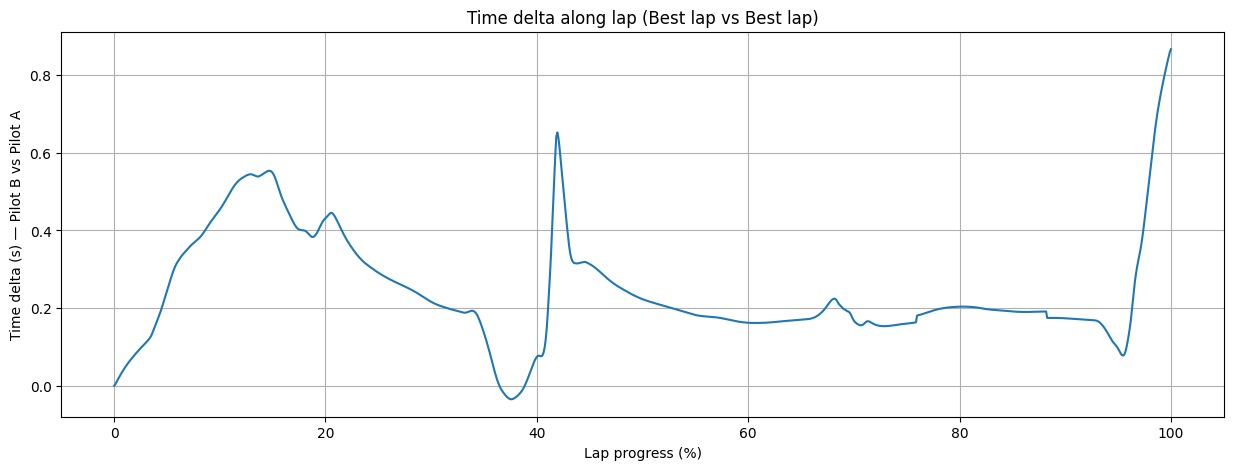

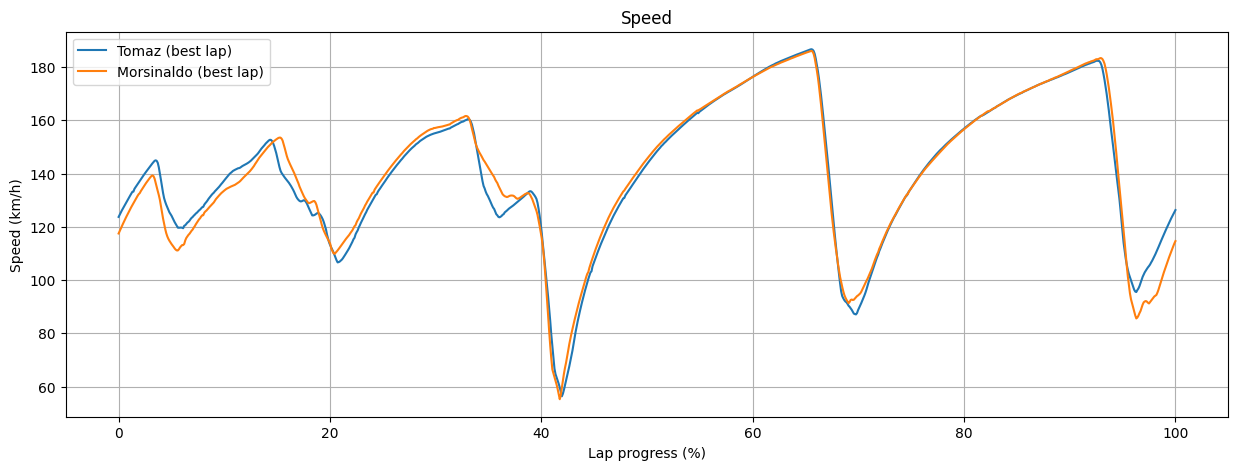

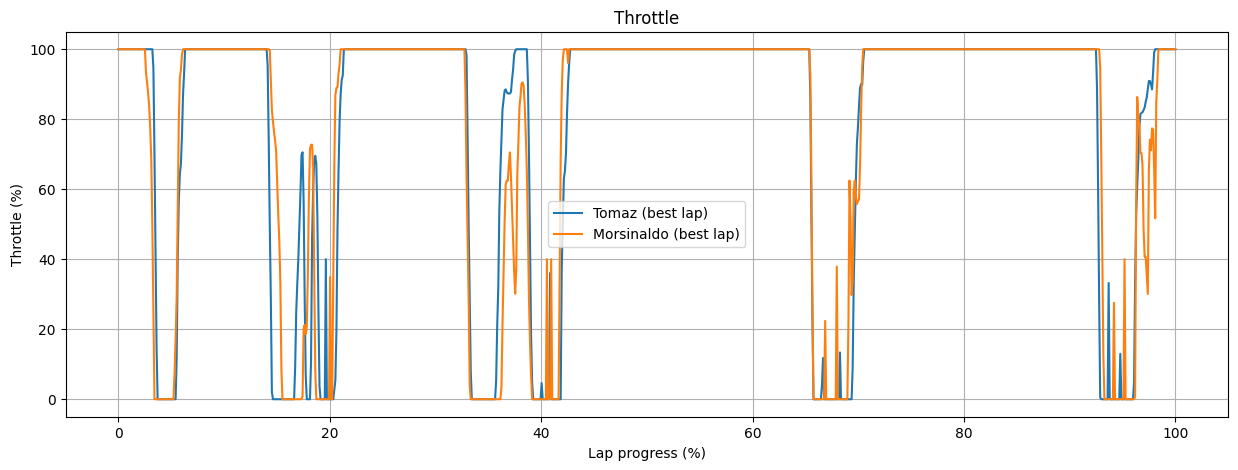

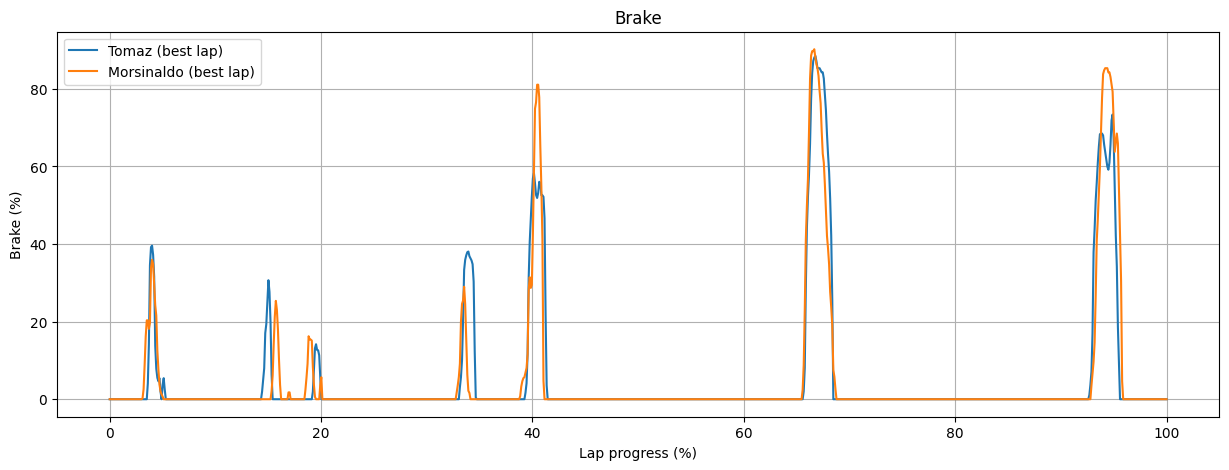

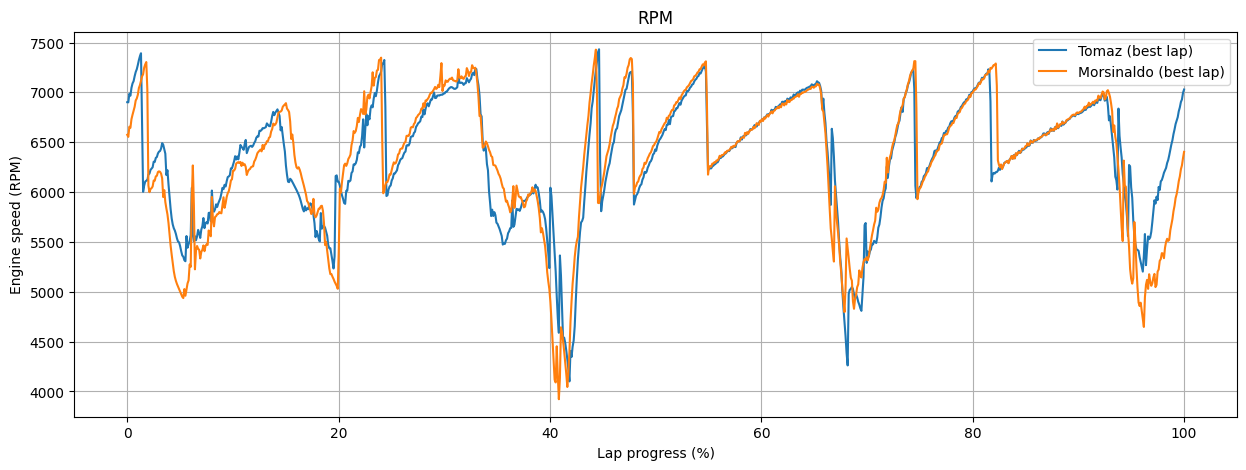

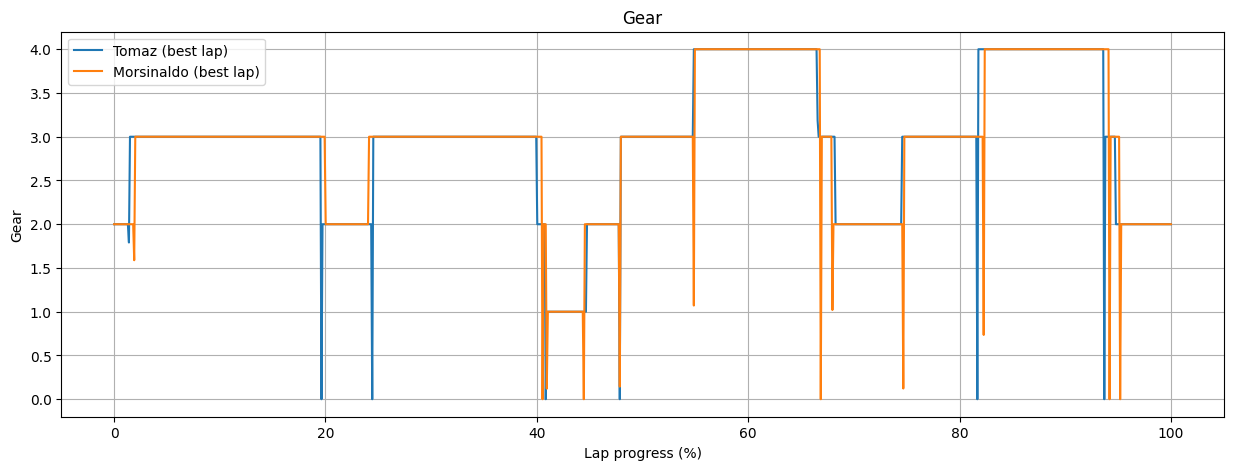

In [68]:
# --- Piloto A ---
lap_df_A = build_lap_validity_table(tomaz_df)
best_row_A = lap_df_A[lap_df_A["Valid"]].sort_values("LapTime_s").iloc[0]
best_lap_A = int(best_row_A["Lap"])

# --- Piloto B ---
lap_df_B = build_lap_validity_table(morsinaldo_df)
best_row_B = lap_df_B[lap_df_B["Valid"]].sort_values("LapTime_s").iloc[0]
best_lap_B = int(best_row_B["Lap"])

print(f"Piloto A - Best lap: {best_lap_A} ({format_laptime(best_row_A['LapTime_s'])})")
print(f"Piloto B - Best lap: {best_lap_B} ({format_laptime(best_row_B['LapTime_s'])})")

# Alinhamento por distância
grid = np.linspace(0.0, 1.0, BASE_GRID_LEN)

g_A = tomaz_df[tomaz_df["Lap"] == best_lap_A]
g_B = morsinaldo_df[morsinaldo_df["Lap"] == best_lap_B]

interp_A = align_lap_by_dist(g_A, grid)
interp_B = align_lap_by_dist(g_B, grid)


# Time-loss curve (target vs reference)
time_loss = interp_B["t_rel"] - interp_A["t_rel"]

plt.figure(figsize=(15, 5))
plt.plot(grid * 100.0, time_loss)
plt.xlabel("Lap progress (%)")
plt.ylabel("Time delta (s) — Pilot B vs Pilot A")
plt.title("Time delta along lap (Best lap vs Best lap)")
plt.grid(True)
plt.show()

def quick_plot(yA, yB, label, ylab):
    plt.figure(figsize=(15, 5))
    plt.plot(grid * 100.0, yA, label="Tomaz (best lap)")
    plt.plot(grid * 100.0, yB, label="Morsinaldo (best lap)")
    plt.xlabel("Lap progress (%)")
    plt.ylabel(ylab)
    plt.title(label)
    plt.legend()
    plt.grid(True)
    plt.show()

quick_plot(interp_A["speed"],    interp_B["speed"],    "Speed",    "Speed (km/h)")
quick_plot(interp_A["throttle"], interp_B["throttle"], "Throttle", "Throttle (%)")
quick_plot(interp_A["brake"],    interp_B["brake"],    "Brake",    "Brake (%)")
quick_plot(interp_A["RPM"],interp_B["RPM"],"RPM","Engine speed (RPM)")
quick_plot(interp_A["Gear"],interp_B["Gear"],"Gear","Gear")

